<center><img src="https://www.ifrax.it/scuola.png"></center>
<h1>Computer Vision and Language Model Project</h1>

Developed as part of the _Multimedia Information Retrieval and Computer Vision_ course (A.Y.2025-2026, prof. Nicola Tonellotto). Master's Degree in *Artificial Intelligence and Data Engineering* (School of Engineering, University of Pisa)

**» Group name**: `Rosenblatt` (in honour of Frank Rosenblatt, father of *Deep Learning*)

**» Authors of the project**: `Nilo Fabiano` `Gabriele Frassi` `Samuele Marchi` `Lorenzo Valtriani`







## **0. Project Idea**
The objective of this project is to develop an image generation system capable of performing spatial completion, specifically reconstructing the right-hand side of an image given its left-hand context. The concept inspiration came from Photoshop’s Generative Fill, which generates content within a user-defined selection, our approach leverages a Two-Stage architecture. First, we employ a Vector Quantized Variational Autoencoder (VQ-VAE) to discretize the image space into a structured codebook. Then, a Transformer-based Language Model (LM), following the GPT architecture, is trained on that specific codebook, to predict these latent tokens autoregressively.
This methodology aligns with the framework offered by OpenAI’s ImageGPT that yields remarkably coherent results.

# **1. Environment Setting**

## 1.1. Python Libraries
The first step is installing all the Python libraries required for the subsequent sections of this notebook. Each import is followed by a short description of the library's purpose in our code.

In [ ]:
import sys, subprocess

# Installing torchmetrics package
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "torchmetrics"],
    stdout=subprocess.DEVNULL, stderr=subprocess.PIPE
)

# Miscellaneous
import os, shutil, glob, re, math, time, string, random, statistics, heapq, pickle, csv
from collections import Counter, defaultdict
from bisect import bisect_left
from typing import List, Tuple, Dict

# Data Analysis and Visualization
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import humanize
from scipy import stats as st
from tqdm.auto import tqdm

# Pytorch and Computer Vision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset, Subset
from torchvision import datasets, transforms
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

# Class Persistent_Storage
import gdown
from google.colab import drive

## 1.2. Profile decorator
The `profile` decorator is a utility designed to monitor performance by measuring a function's execution time. Instead of returning raw seconds, it dynamically formats the duration into a human-readable string.

In [ ]:
def profile(f):
    def f_timer(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        elapsed = end - start

        if elapsed < 60:
            time_str = f"{elapsed:.3f}s"
        elif elapsed < 3600:
            minutes = int(elapsed // 60)
            seconds = elapsed % 60
            time_str = f"{minutes}m {seconds:.3f}s"
        else:
            hours = int(elapsed // 3600)
            minutes = int((elapsed % 3600) // 60)
            seconds = elapsed % 60
            time_str = f"{hours}h {minutes}m {seconds:.3f}s"

        print(f"{f.__name__} ({time_str})")
        return result
    return f_timer

## 1.3. Persistent storage using Pickle files and Google Drive
To streamline notebook analysis and avoid executing time-consuming functions, we implemented the `Persistent_Storage` class, which allows to save data structures in a persistent way using *Pickle files*. Indeed Google Colab cleans main and disk memory when refreshed. A special method for saving *run files* is also defined. The method `get_base_path` allows for coh

Two possible operational modes are available (chosen during the instantiation of the class):
- **Drive mode**, _adopted by project group members_.
  
  Let Google Colab connects to the user Google Drive to allow saving data structures in a persistent and shared enviroment with `save_data_structure` and `save_run_file` methods.  Data structures can be retrieved in future executions with `load_data_structure` method, avoiding to execute all blocks in the notebook.

- **Non-Drive mode**, _adopted by external users_.

  Downloads a directory with pre-processed data structures in the local Colab disk. Methods `save_data_structure`, `save_run_file` and `load_data_structure` will use as target the disk memory. So refreshing the environment will cause to lost all progress.

The utility class is used in following blocks:
- Execution of `build_index` function in _2.1. Construction_ (_2. Inverted Index_)
- Execution of `compute_max_score` function in _3.2.2. DaaT implementation with WAND optimization_ (_3.2. Query Processing_)
- Execution of `create_run_file` function in _5.2. Run File Generation_ (_5. Evaluate the Effectiveness_)



In [ ]:
class Persistent_Storage:
  def __init__(self, drive_mode = False):
    self.__drive_mode = drive_mode

    # Drive mode (True) vs Non-Drive mode (False)
    if self.__drive_mode:
      drive.mount('/content/drive', force_remount = True)
      self.__base_path = os.path.join('/content/drive','MyDrive','Progetto Multimedia Information','CV')
    else:
      url = 'https://drive.google.com/drive/folders/1DIbeeFVVwyrgyik5sS9QVsmazmtujRy1?usp=sharing'
      gdown.download_folder(url, quiet = False, use_cookies = False)
      self.__base_path = os.path.join('/content','CV')

    print("")
    print("Base path: ", self.__base_path)

  def get_base_path(self): # Returns private variable base_path
    return self.__base_path

  ######################################################
  ############## METHODS FOR PICKLE FILES ##############
  ######################################################

  def save_data_structures(self, data_dict): # Dealing with more data structures in an elegant way
    for name, ds in data_dict.items():
      self.save_data_structure(ds, name)

  def load_data_structures(self, names_list): # Dealing with more data structures in an elegant way
    return [self.load_data_structure(name) for name in names_list]

  @profile
  def save_data_structure(self, ds, name):
    os.makedirs(self.__base_path, exist_ok = True) # Creation of dirs (if necessary)

    # Write operation
    with open(os.path.join(self.__base_path, f"{name}.pickle"), 'wb') as f:
        pickle.dump(ds, f)

    print(f"[DONE] Data structure {name} saved to {self.__base_path}")

  def load_data_structure(self, name, verbose = True):
    # Read operation
    with open(os.path.join(self.__base_path, f"{name}.pickle"), 'rb') as f:
        ds = pickle.load(f)

    if verbose == True:
      print(f"[DONE] Data structure {name} loaded from {self.__base_path}")
    return ds

persistent_storage = Persistent_Storage(drive_mode = False)

Retrieving folder contents


Retrieving folder 1oXjpfP2BvmBlF3Zjd5WzLduK9gpvvBMu checkpoints
Processing file 1U4fvW2z5uXI1C3nzawmmIq7pzrZWLzpc v1_beam_batch_0.pt
Processing file 1CM5PVdaXLu1f_QkR3IBEsh6vAiO66hrQ v1_beam_batch_1.pt
Processing file 1MMOpaO4elL51oEEKs1-w0bEh35TH47Pv v2_beam_batch_0.pt
Processing file 1W3S4k5Wwd1rgluMfkZvYhxc-MAlYsm_A v2_beam_batch_1.pt
Retrieving folder 1Zy8TnnpKIPbfcClGdVYAVe3OC4LBvKcc datasets
Processing file 1alvK-C8HkPxkgTnZhxcUUzP4GpDoKVG9 dataset_original.pt
Processing file 1ANvjVSz_GTgg9x5zRR4iyqT0wSp58KFx dataset_reconstract.pt
Processing file 1mtK09fxz-ymP1PD9eT_EdNZ5xmLCJ6D8 final_batch_generation_time.pickle
Processing file 1FE1DiA7CKxbQGqxpp3DIOthN5xqbdpAM final_dataset_generated.pt
Processing file 1RL5SieaSRglj5SKmzwYoR9h7vvl4M53B final_original.pt
Processing file 1Q99oL6jes6AekLFd5pfVvZrjKaK6UcKl final_reconstract.pt
Processing file 1l5YkeCbBfZbndZNyJoxW62yzYsPJhNsl v1_beam_batch_generation_time.pickle
Processing file 1_a4gAu3S_YNEMlaTMdp23nubAfo-f5jt v1_beam_dataset_ge

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1U4fvW2z5uXI1C3nzawmmIq7pzrZWLzpc
To: /content/CV/checkpoints/v1_beam_batch_0.pt
100%|██████████| 3.25M/3.25M [00:00<00:00, 24.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CM5PVdaXLu1f_QkR3IBEsh6vAiO66hrQ
To: /content/CV/checkpoints/v1_beam_batch_1.pt
100%|██████████| 3.25M/3.25M [00:00<00:00, 20.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MMOpaO4elL51oEEKs1-w0bEh35TH47Pv
To: /content/CV/checkpoints/v2_beam_batch_0.pt
100%|██████████| 5.90M/5.90M [00:00<00:00, 29.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1W3S4k5Wwd1rgluMfkZvYhxc-MAlYsm_A
To: /content/CV/checkpoints/v2_beam_batch_1.pt
100%|██████████| 5.90M/5.90M [00:00<00:00, 21.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1alvK-C8HkPxkgTnZhxcUUzP4GpDoKVG9
To: /content/CV/datasets/dataset_original.pt
100%|██████████| 4.2


Base path:  /content/CV



Download completed


## 1.4 Randomness and Device setting

In [ ]:
SEED=42

#About devices
print(f"Gpu availability: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"

Gpu availability: True


# **2. Trasformation Image to Token**
The first phase of the project aims to build a discrete vocabulary of tokens on which to train the Large Language Model. Unlike traditional language models, which operate on text sequences, our GPT model is designed to generate images. It is therefore necessary to define a procedure that allows us to transform the continuous domain of images into a discrete representation compatible with the architecture of an autoregressive model. To meet these requirements, the Vector Quantized Variational Autoencoder (VQ-VAE) technology was chosen.

VQ-VAE is a variant of the Variational Autoencoder that introduces a vector quantization process into the latent space. The architecture is composed of three main elements:
* **Encoder**: Maps the input image x into a latent representation z_e(x)
* **Codebook**: Finite set of K quantized latent vectors, where K represents the size of the vocabulary.
* **Decoder**: Reconstructs the image from the quantized latent representation.

Because an image contains structured spatial information, it is not represented by a single token, but rather by a two-dimensional array of discrete tokens, each of which encodes a local portion of the image.




## 2.1. Dataset building
The dataset chosen was ImageNet32; a reduced and preprocessed version of the ImageNet dataset, designed for experiments where computational cost is desired while maintaining the semantic structure of the original dataset. The images are RGB and have a resolution of 32x32.
Unlike CIFAR-10, ImageNet32 images are generally more semantically and visually complex, and the dataset is significantly larger. This greater variety and size are crucial when training deep learning models, especially when considering large architectures, which require large amounts of data to learn.

To download the ImageNet32 dataset, you must register on the website https://image-net.org/ and download the datasets directly from there.






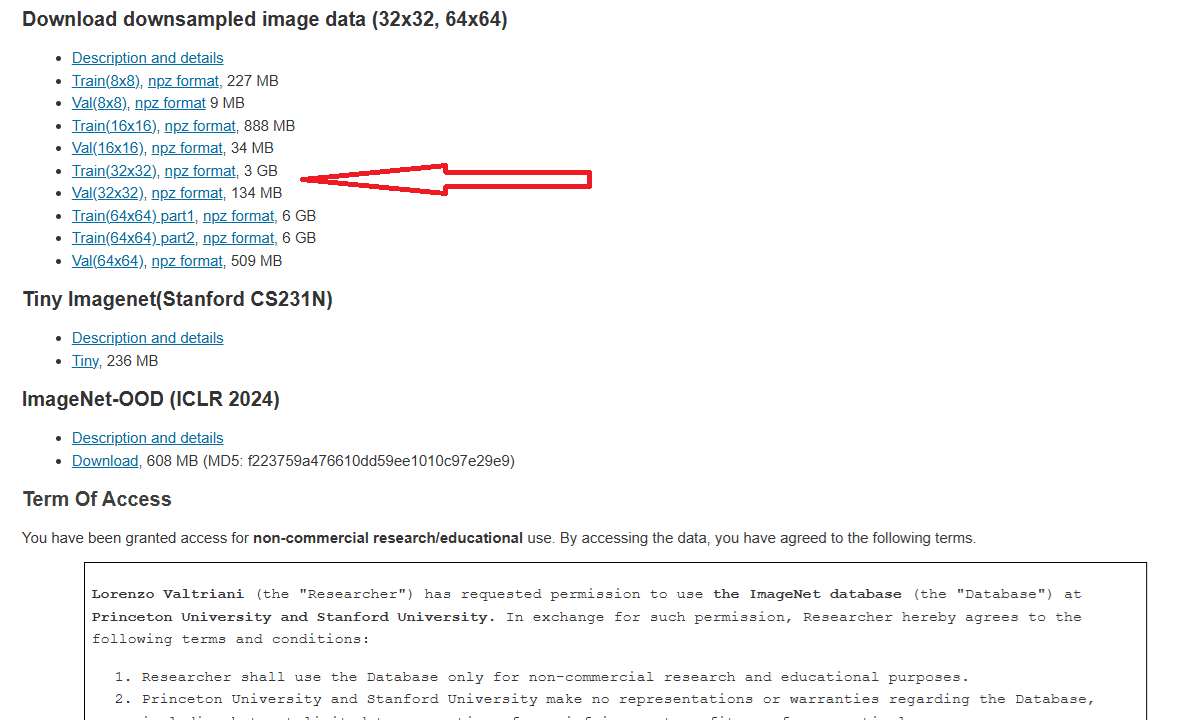

Note that the training dataset would contain 1.281.167 images, but we only used 30% of them to avoid excessively long executions.

In [ ]:
@profile
def build_dataset():
  transform = transforms.Compose([
    transforms.ToTensor()
  ])

  # Download the ImageNet32 dataset
  class ImageNet32(Dataset):
    def __init__(self, root, train=True, transform=None):
        npz = np.load(root)
        self.data = npz["data"]
        self.labels = npz["labels"]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        img = img.reshape(3, 32, 32).transpose(1, 2, 0)

        if self.transform:
            img = self.transform(img)

        return img, int(self.labels[idx])

  # Lista dei dataset
  datasets_list = [
      ImageNet32(root=f"{persistent_storage.get_base_path()}/imagenet32/train_data_1.npz", train=True, transform=transform),
      ImageNet32(root=f"{persistent_storage.get_base_path()}/imagenet32/train_data_2.npz", train=True, transform=transform),
      ImageNet32(root=f"{persistent_storage.get_base_path()}/imagenet32/train_data_3.npz", train=True, transform=transform)
  ]

  # Union into a single train_data
  train_data = ConcatDataset(datasets_list)

  # Testing data
  test_data = ImageNet32(root=f"{persistent_storage.get_base_path()}/imagenet32/val_data.npz", train=False, transform=transform)

  print("Training data:", len(train_data), "images")
  print("Test data:", len(test_data), "images")
  print(f"Image shape: {train_data[0][0].shape}\n")

  print(train_data[0][0])
  print()
  return train_data, test_data

train_data, test_data = build_dataset()

Training data: 384348 images
Test data: 50000 images
Image shape: torch.Size([3, 32, 32])

tensor([[[0.0471, 0.0784, 0.1647,  ..., 0.1490, 0.1373, 0.1373],
         [0.0941, 0.0784, 0.0902,  ..., 0.1647, 0.1098, 0.0588],
         [0.0745, 0.0627, 0.0784,  ..., 0.2000, 0.1725, 0.1216],
         ...,
         [0.5451, 0.5725, 0.5451,  ..., 0.6039, 0.6431, 0.5529],
         [0.5137, 0.5412, 0.5059,  ..., 0.4235, 0.4902, 0.5804],
         [0.5451, 0.5569, 0.4784,  ..., 0.5373, 0.4784, 0.4275]],

        [[0.0863, 0.1020, 0.1608,  ..., 0.0549, 0.0510, 0.0588],
         [0.1176, 0.1020, 0.1020,  ..., 0.1451, 0.0980, 0.0588],
         [0.1020, 0.1020, 0.1098,  ..., 0.1882, 0.1608, 0.1176],
         ...,
         [0.4549, 0.4157, 0.3922,  ..., 0.1843, 0.2000, 0.1490],
         [0.4667, 0.4431, 0.3686,  ..., 0.1020, 0.1294, 0.1686],
         [0.5059, 0.5059, 0.4118,  ..., 0.1490, 0.1137, 0.1765]],

        [[0.0314, 0.0471, 0.1137,  ..., 0.0431, 0.0392, 0.0431],
         [0.0706, 0.0510, 0.0510

Here we split the dataset into training, validation, and test sets. The split between training and validation is performed using a fixed SEED, ensuring reproducibility of the partitioning process.

By fixing the random seed, we guarantee that the train/validation split remains identical across different runs. This allows the training process to be resumed on the same model over multiple sessions, even if the notebook or execution environment has been restarted in the meantime. In other words, the data samples assigned to the training and validation sets remain consistent, enabling continuity of the training procedure across different days without altering the underlying data distribution.

In [ ]:
# split 90% train, 10% val for the training phase
train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# define the train, validation and test loader to use in the notebook
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=2)

Here there are some examples of images of the train dataset

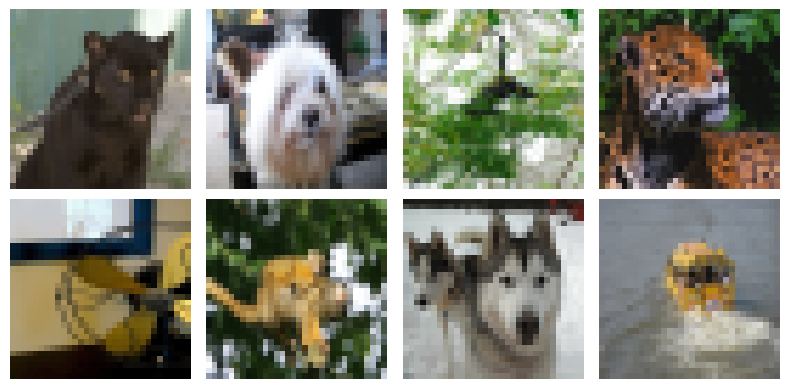

In [ ]:
def show_random_images(dataset, n=8):
    random.seed(SEED)
    indices = random.sample(range(len(dataset)), n)

    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 2, rows * 2))

    for i, idx in enumerate(indices):
        img, _ = dataset[idx]
        img = img.permute(1, 2, 0)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_data)

## 1.2. Model definition (VQ-VAE)
A fundamental aspect of this architecture concerns how the image is represented in the latent discrete space. After passing through the encoder and the quantization step, each image is represented as a quantized latent matrix, whose spatial dimensions depend on the downsampling factor of the encoder. The choice of the size of this latent matrix is crucial, as it directly determines the number of discrete elements used to describe the image and therefore the length of the resulting token sequence when the model is combined with a GPT.

In principle, one could represent each individual pixel as a quantized discrete element, effectively treating every pixel as a token. However, this choice would lead to very long sequences (for example, a 32×32 image corresponds to 1024 tokens in the case of ImageNet32), significantly increasing the computational cost of any subsequent sequence model. In particular, an autoregressive model would need to handle a context length of at least 1024 tokens in order to model the full image without truncation. This requirement is non-trivial: for instance, GPT-1 was designed with a maximum context window of 512 tokens, which would not even be sufficient to cover a single 32×32 image represented at pixel level.

Using patches offers several advantages. First of all, it reduces the sequence length, making autoregressive modeling computationally feasible. For example, reducing a 32×32 image to an 8×8 or 16x16 latent grid results in only 64 or 256 discrete tokens per image. The choice of patch size represents a trade-off; larger patches reduce the number of tokens and computational cost but risk losing fine-grained spatial details, potentially degrading reconstruction quality.

For high-resolution images, using relatively large patches results in a proportionally smaller loss of detail than for low-resolution images. In these cases, each patch covers a smaller fraction of the overall image, allowing for good reconstruction quality while reducing the number of tokens for the autoregressive model.

In this section we will analyze more in details the implementation and the role of the three components of `VQ-VAE`.

### 1.2.1. Encoder
In the context of a VQ-VAE, the encoder is responsible for transforming the high-dimensional input image into a *continuous latent representation*, which will later be quantized by the vector quantizer. In our setup, the input image has shape `(3, 32, 32)` and is spatially downsampled by the encoder to a latent tensor of shape `(latent_dim, 8, 8)` or `(latent_dim, 16, 16)`, depending on the chosen patch size.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels, latent_dim, patch_size):
        super().__init__()

        # Check of parameters
        if patch_size not in [2, 4]:
            raise ValueError("patch_size must be 2 or 4")

        # We define the parameters that depends on the patch_size
        stride_val = 1 if patch_size == 2 else 2
        kernel_val = 3 if patch_size == 2 else 4

        self.encoder = nn.Sequential(
            # First convolutional layer:
            # 32x32 -> 16x16
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),

            # Effettuo la normalizzazione su gruppi separati di 8 canali
            nn.GroupNorm(8, 64),
            nn.ReLU(),

            # Second convolutional layer:
            # 16x16 -> 16x16 if patch_size is 2
            # 16x16 -> 8x8 if patch_size is 4
            nn.Conv2d(64, 128, kernel_size=kernel_val, stride=stride_val, padding=1),
            nn.GroupNorm(16, 128),
            nn.ReLU(),

            # Third convolutional layer:
            # 16x16 --> 16x16 if patch_size is 2
            # 8x8 -> 8x8 if patch_size is 4
            nn.Conv2d(128, latent_dim, kernel_size=3, padding=1)
        )

        self.ln = nn.LayerNorm(latent_dim)

    def forward(self, x):
        # x: (B, 3, 32, 32) --> (B, latent_dim, H, W)
        z_e = self.encoder(x)

        # We permute the tensor because we want to normalize each patch
        # on the channels, and layer norm works on the last dimension
        # (B, C, H, W) -> (B, H, W, C)
        z_e = z_e.permute(0, 2, 3, 1).contiguous()
        z_e = self.ln(z_e)

        # Back to (B, C, H, W) for the continuous embedding vector
        return z_e.permute(0, 3, 1, 2).contiguous()

### 1.2.2. Vector Quantizer
In the context of a VQ-VAE, the vector quantizer has the task of transforming the continuous latent representation produced by the encoder *into a discrete representation*, using a finite set of vectors called a codebook. The shape of the tensor remains the same.



In [ ]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_tokens, latent_dim):
        super().__init__()
        self.num_tokens = num_tokens
        self.latent_dim = latent_dim

        # Embedding matrix for embedding token give its one hot embedding
        self.codebook = nn.Embedding(num_tokens, latent_dim)
        # Initilize vectors of codebook with random uniform values
        nn.init.uniform_(self.codebook.weight, -1.0 / latent_dim, 1.0 / latent_dim)

    def forward(self, z_e):
        B, C, H, W = z_e.shape

        # Each row corresponds to one patch vector
        # (B, H, W, C) --> (B * H * W, C)
        z_e_flattened = z_e.permute(0, 2, 3, 1).contiguous().view(-1, C)

        # Compute squared Euclidean distance between each patch vector and all codebook entries
        # Efficiently: ||z - e||^2 = ||z||^2 + ||e||^2 - 2*z*e
        distances = (
            torch.sum(z_e_flattened**2, dim=1, keepdim=True)
            + torch.sum(self.codebook.weight**2, dim=1)
            - 2 * torch.matmul(z_e_flattened, self.codebook.weight.t())
        )

        # We select the closest token id for each continuous embedding vector
        tokens = torch.argmin(distances, dim=1)
        # We get for each continuous embedding vector the relative quatizer embedding vector
        z_q = self.codebook(tokens) # (B * H * W, C)

        # (B * H * W, C) --> (B, H, W, C)
        z_q = z_q.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        # During training, some codebook entries may never be used (dead embeddings)
        if self.training:
            # Not considered for backpropagation
            with torch.no_grad():
                # Contiamo quante volte viene utilizzato ciascun token
                usage = torch.bincount(tokens, minlength=self.num_tokens)
                # The token with 0 usage are considered as dead tokens
                dead_indices = (usage == 0).nonzero(as_tuple=True)[0]
                if len(dead_indices) > 0:
                    # Number of token to resurrect
                    # Se hai 100 token morti ma solo 64 patch nell'immagine, ne puoi riattivare al massimo 64.
                    num_to_resurrect = min(len(dead_indices), z_e_flattened.size(0))

                    # Si prendono gli indici dei token che sono stati identificati come "inutilizzati" (frequenza zero nel batch).
                    indices_to_resurrect = dead_indices[:num_to_resurrect]

                    # Si scelgono a caso dei vettori reali dall'input corrente (z_e). Questi sono vettori che l'encoder ha appena generato "nel mondo reale" dei dati.
                    random_indices = torch.randperm(z_e_flattened.size(0))[:num_to_resurrect]

                    # Si sovrascrivono i token morti con i vettori presi dall'input.
                    self.codebook.weight.data[indices_to_resurrect] = z_e_flattened[random_indices].clone()

        # Return the discrete embedding vector and the index of the token for each patch
        return z_q, tokens.view(B, H, W)


### 1.2.3. Decoder
In the context of a VQ-VAE, the decoder has the task of transforming the discrete latent representation produced by the vector quantizer back into an image in the original space. In our setup, the input image has shape `(latent_dim, 8, 8)` or `(latent_dim, 16, 16)`, depending on the chosen patch size while the output has the same shape of the original image `(3, 32, 32)`.





In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, out_channels, patch_size):
        super().__init__()

        if patch_size not in [2, 4]:
            raise ValueError("patch_size must be 2 or 4")

        # Upsample + Conv2d is preferred over ConvTranspose2d
        # because ConvTranspose2d can easily produce checkerboard artifacts

        layers = [
            # First Upscaling (each pixel is copied into a 2x2 block)
            # 8x8 -> 16x16 if patch is 4
            # 16x16 -> 32x32 if patch is 2
            nn.Upsample(scale_factor=2, mode='nearest'),
            # Conv2d refines the feature map without changing spatial size
            nn.Conv2d(latent_dim, 128, kernel_size=3, padding=1),
            nn.GroupNorm(16, 128),
            nn.ReLU(),
        ]

        # Second Upscaling (is conditional)
        # If patch is 4, 16x16 -> 32x32.
        # If patch is 2, the image is already 32x32, so we use identity (it does nothing).
        if patch_size == 4:
            layers.append(nn.Upsample(scale_factor=2, mode='nearest'))

        # Convolution that dont change spatial size but only the number of channels
        layers.append(nn.Conv2d(128, 64, kernel_size=3, padding=1))
        layers.append(nn.GroupNorm(8, 64))
        layers.append(nn.ReLU())

        # Final Convolution to change number of channels to 3
        layers.append(nn.Conv2d(64, out_channels, kernel_size=3, padding=1))

        self.decoder = nn.Sequential(*layers)

    def forward(self, z_q):
        # z_q: (B, latent_dim, 8, 8) quantized latent feature map
        x = self.decoder(z_q)

        # Clamp output to [0, 1] because PyTorch image tensors typically
        # use this range for pixel intensities, is a type of normalization
        x = x.clamp(0, 1)
        return x

In [ ]:
class VQVAE(nn.Module):
    def __init__(self, in_channels, num_tokens, latent_dim, out_channels, patch_size):
        super().__init__()
        # encoder: maps input images to continuous latent embeddings
        self.encoder = Encoder(in_channels, latent_dim, patch_size)
        # vector quantizer: maps continuous embeddings to nearest codebook vectors
        self.quantizer = VectorQuantizer(num_tokens, latent_dim)
        # decoder: reconstructs images from quantized latent embeddings
        self.decoder = Decoder(latent_dim, out_channels, patch_size)

    def forward(self, x):
        # encode input image to continuous latent space
        z_e = self.encoder(x)  # shape: (B, latent_dim, H, W)

        # quantize the embeddings using the codebook
        z_q, tokens = self.quantizer(z_e)  # z_q: quantized embeddings, tokens: discrete indices

        # straight-through estimator:
        # z_q is not differentiable due to argmin in quantization
        # We use z_q_st for the decoder, but allow gradients to flow into z_e
        # detach() prevents gradients from updating z_q, only z_e receives gradients

        # durante il forward abbiamo z_q_st = z_q
        # durante la backpropagation mi rimane solo z_e
        z_q_st = z_e + (z_q - z_e).detach()

        # decode the straight-through latent embeddings
        recon_x = self.decoder(z_q_st)

        # return
        # recon_x: reconstructed image
        # z_e: continuous embeddings
        # z_q: quantized embeddings
        # tokens: discrete token indices
        return recon_x, z_e, z_q, tokens

### 1.2.4. Loss Function

The loss function of the VQ-VAE combines three main components, each targeting a different part of the model:

1. **Reconstruction Loss**: Measures how close the reconstructed image (`recon_x`) is to the original image (`x`). Typically uses **L1 loss** (mean absolute error) instead of MSE to obtain sharper edges and cleaner details.
  
2. **Codebook Loss**: Measures how well the discrete vectors (`z_q`) match the continuous vectors from the encoder (`z_e`). `z_e` is detached from the computation graph to prevent updating the encoder at this stage; only the **codebook** is updated.

3. **Commitment Loss**: Encourages the encoder to stay close to the codebook vectors. `z_q` is detached to prevent updating the codebook during this step.



In [ ]:
def vqvae_loss(x, recon_x, z_e, z_q, beta, recon_weight):
    # loss that measure the recostruction of the patch
    # we use l1 loss for clean borders (nitidi) rather than mse
    # mean absolute error (mae) is the 1st norm of the difference
    recon_loss = F.l1_loss(recon_x, x)

    # codebook loss
    # we use detach to leaves z_e from the computational graph, to not
    # penalize the encoder in this phase, update parameters of the embedding metrics
    codebook_loss = F.mse_loss(z_q, z_e.detach())

    # commitment loss
    # we use detach to leaves z_q from the computational graph, to not penalize
    # the codebook in this phase
    commitment_loss = F.mse_loss(z_e, z_q.detach())

    # total loss function
    # beta and recon_weight are use to set importants for that specific parts
    loss = recon_weight * recon_loss + codebook_loss + beta * commitment_loss

    return loss, recon_loss, codebook_loss, commitment_loss

## 1.3. Hyperparameter Configuration

Defining a dictionary for hyperparameters allows for easy management and modification of all experimental settings in one place. The most important hyperparameters are:
*   `latent_dim`: Represent the number of channels for a single patch, in other words the size of the latent value, whether continuous or quantized. Set to *128*.
*   `num_tokens`: It represents the maximum number of quantized latent vectors that the codebook contains. Set to *1024*.
*   `patch_dim`: It represents the area of the patch.



In [ ]:
cv_configurations = {
    '4x4': {
        'training': False,
        'load_model': True,
        'name': 'vqvae_imagenet_v1_4x4_1024_128',
        'num_epochs': 10,
        'batch_size': 256,
        'learning_rate': 2e-4,
        'beta': 0.25,
        'recon_weight': 1.5,
        'patch_size': 4,
        'num_tokens': 1024,
        'latent_dim': 128,
        'in_channels': 3,
        'out_channels': 3
    },
    '2x2': {
        'training': False,
        'load_model': True,
        'name': 'vqvae_imagenet_v2_2x2_1024_128',
        'num_epochs': 10,
        'batch_size': 256,
        'learning_rate': 2e-4,
        'beta': 0.25,
        'recon_weight': 1.5,
        'patch_size': 2,
        'num_tokens': 1024,
        'latent_dim': 128,
        'in_channels': 3,
        'out_channels': 3
    }
}

In [ ]:
# Initialize the VQ-VAE models
vqvae_models = {}
for model in ["4x4", "2x2"]:
  cv_configuration = cv_configurations[model]
  vqvae_model = VQVAE(
      in_channels=cv_configuration['in_channels'],
      num_tokens=cv_configuration['num_tokens'],
      latent_dim=cv_configuration['latent_dim'],
      out_channels=cv_configuration['out_channels'],
      patch_size=cv_configuration['patch_size']
  ).to(device)

  # If you want load a model already trained
  if cv_configuration['load_model']:
    # Load pretrained weights if are avaiable
    model_path = f"{persistent_storage.get_base_path()}/{cv_configuration['name']}.pth"
    if os.path.exists(model_path):
      vqvae_model.load_state_dict(
          torch.load(model_path, map_location=device)
      )

  vqvae_models[model] = vqvae_model

Here we can see the number of parameters that VQ-VAE model contains:

In [ ]:
def count_parameters(model):
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    num_bytes = sum(p.numel() * p.element_size() for p in model.parameters() if p.requires_grad)

    for unit in ['B', 'KB', 'MB', 'GB']:
        if num_bytes < 1024:
            size_str = f"{num_bytes:.2f} {unit}"
            break
        num_bytes /= 1024

    return num_params, size_str

In [ ]:
for model, vqvae_model in vqvae_models.items():
  enc_params, enc_size = count_parameters(vqvae_model.encoder)
  quant_params, quant_size = count_parameters(vqvae_model.quantizer)
  dec_params, dec_size = count_parameters(vqvae_model.decoder)
  total_params, total_size = count_parameters(vqvae_model)

  print(f"Model: {model}")
  print(f"Encoder parameters: {enc_params:,} ({enc_size})")
  print(f"Quantizer parameters: {quant_params:,} ({quant_size})")
  print(f"Decoder parameters: {dec_params:,} ({dec_size})")
  print(f"-"*50)
  print(f"Total parameters: {total_params:,} ({total_size})\n")

Model: 4x4
Encoder parameters: 282,560 (1.08 MB)
Quantizer parameters: 131,072 (512.00 KB)
Decoder parameters: 223,491 (873.01 KB)
--------------------------------------------------
Total parameters: 637,123 (2.43 MB)

Model: 2x2
Encoder parameters: 225,216 (879.75 KB)
Quantizer parameters: 131,072 (512.00 KB)
Decoder parameters: 223,491 (873.01 KB)
--------------------------------------------------
Total parameters: 579,779 (2.21 MB)



## 1.4. Training, Validation and Testing the models


### 1.4.1. Trainining the network
In this section, the models are trained using the training dataset introduced in the previous section. The training process runs for `10 epochs`, and at the end of each epoch the loss is also evaluated on the validation set.

To prevent overfitting and ensure better generalization, we adopt a model checkpointing strategy based on validation performance. Specifically, after each epoch we compare the current validation loss with the best validation loss observed so far. The model is saved only if it achieves the lowest validation loss in absolute terms up to that point.

In [ ]:
def vqvae_training(name_model):
  vqvae_model = vqvae_models[name_model]
  cv_configuration = cv_configurations[name_model]

  best_val_loss = float("inf")
  best_model_state = None
  optimizer = torch.optim.Adam(vqvae_model.parameters(), lr=cv_configuration['learning_rate'])

  if cv_configuration["training"] == False :
        return

  print(f"Training of the {name_model} model starts!\n")

  for epoch in range(cv_configuration["num_epochs"]):

      # #### TRAINING PHASE ####
      vqvae_model.train()
      total_train_loss = 0.0

      pbar = tqdm(
          enumerate(train_loader),
          total=len(train_loader),
          desc=f"Epoch {epoch+1}/{cv_configuration['num_epochs']}"
      )

      for i, (images, _) in pbar:
          images = images.to(device)

          recon_images, z_e, z_q, tokens = vqvae_model(images)
          loss, _, _, _ = vqvae_loss(
              images,
              recon_images,
              z_e,
              z_q,
              cv_configuration["beta"],
              cv_configuration["recon_weight"]
          )

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          total_train_loss += loss.item()
          pbar.set_postfix({"loss": f"{loss.item():.4f}"})

      avg_train_loss = total_train_loss / len(train_loader)

      # #### VALIDATION PHASE ####
      vqvae_model.eval()
      total_val_loss = 0.0

      with torch.no_grad():
          for images, _ in val_loader:
              images = images.to(device)

              recon_images, z_e, z_q, tokens = vqvae_model(images)
              val_loss, _, _, _ = vqvae_loss(
                  images,
                  recon_images,
                  z_e,
                  z_q,
                  cv_configuration["beta"],
                  cv_configuration["recon_weight"]
              )
              total_val_loss += val_loss.item()

      avg_val_loss = total_val_loss / len(val_loader)

      # #### SELECTION PHASE ####
      # If the model has the best validation loss, it is saved on the disk
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          best_model_state = {
              k: v.detach().cpu().clone()
              for k, v in vqvae_model.state_dict().items()
          }

          vqvae_model.load_state_dict(best_model_state)
          torch.save(vqvae_model.state_dict(), f"{persistent_storage.get_base_path()}/{cv_configuration["name"]}.pth")

      print(
          f"Epoch {epoch+1} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Best Val: {best_val_loss:.4f}"
      )

  # #### LOAD and SAVE BEST MODEL ####
  print(f"\nLoaded best model with val loss = {best_val_loss:.4f}")

In [ ]:
for model_name in ["4x4", "2x2"]:
  vqvae_training(model_name)

Both models were trained until they reached their optimal validation loss, and the model was saved just before overfitting began.

### 1.4.2. Testing
Now we test the two models


In [ ]:
def vqvae_testing(name_model):
  vqvae_model = vqvae_models[name_model]
  vqvae_model.eval()
  cv_configuration = cv_configurations[name_model]

  total_loss = 0.0
  with torch.no_grad():
      for images, _ in test_loader:
          images = images.to(device)

          recon_images, z_e, z_q, tokens = vqvae_model(images)

          loss, _, _, _ = vqvae_loss(
              images,
              recon_images,
              z_e,
              z_q,
              cv_configuration["beta"],
              cv_configuration["recon_weight"]
          )
          total_loss += loss.item()

  avg_loss = total_loss / len(test_loader)
  print(f"Test set average loss on {model_name}: {avg_loss:.4f}")

In [ ]:
for model_name in ["4x4", "2x2"]:
  vqvae_testing(model_name)

Test set average loss on 4x4: 0.1324
Test set average loss on 2x2: 0.0875


We observe that the test loss is significantly lower for the model that operates on 2×2-sized patches.

## 1.5. Show Results

Now we demonstrate the power of VQ VAE in the recostruction of the image from the test set

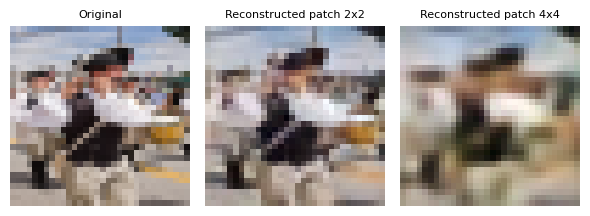

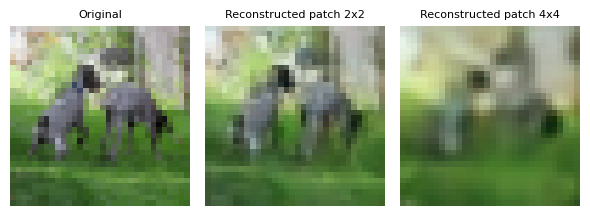

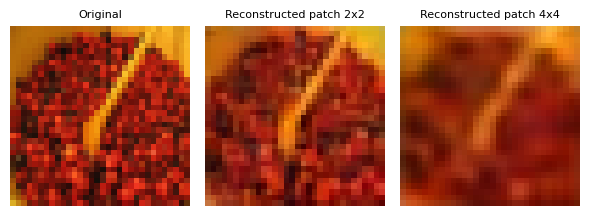

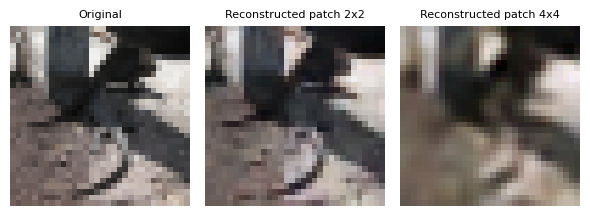

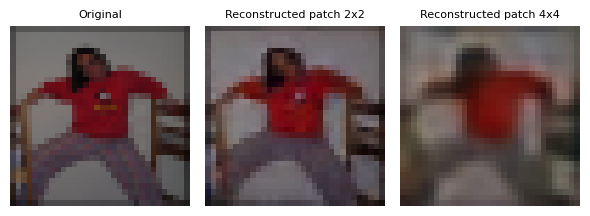

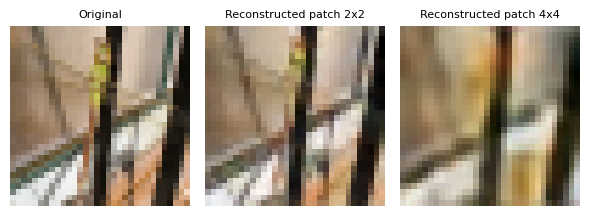

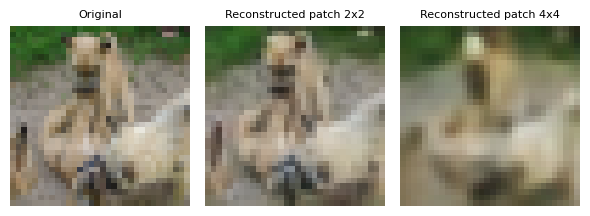

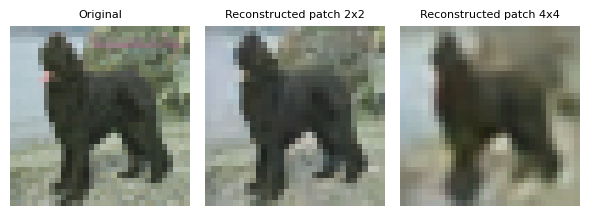

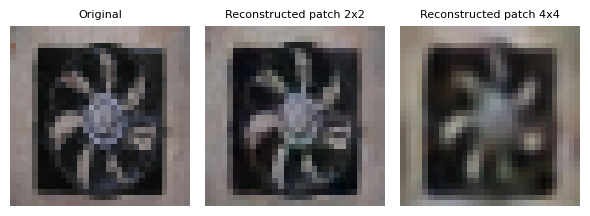

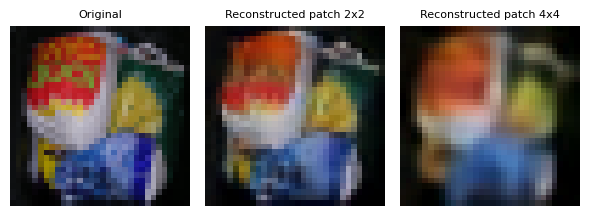

In [ ]:
def show_three_images(original_images, reconstructed_images2x2, reconstructed_images4x4):
    img1 = original_images.squeeze(0).permute(1, 2, 0).detach().cpu()
    img2 = reconstructed_images2x2.squeeze(0).permute(1, 2, 0).detach().cpu()
    img3 = reconstructed_images4x4.squeeze(0).permute(1, 2, 0).detach().cpu()

    fig, axes = plt.subplots(1, 3, figsize=(6, 4))

    axes[0].imshow(img1)
    axes[0].set_title("Original", fontsize=8)
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title("Reconstructed patch 2x2", fontsize=8)
    axes[1].axis("off")

    axes[2].imshow(img3)
    axes[2].set_title("Reconstructed patch 4x4", fontsize=8)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

def visualize_reconstructions(dataset, num_samples):
    for model in vqvae_models.values():
        model.eval()

    random.seed(SEED)
    indices = random.sample(range(len(dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            # (C, H, W)
            img, _ = dataset[idx]
            img_input = img.unsqueeze(0).to(device)

            vqvae_model2x2 = vqvae_models["2x2"]
            vqvae_model4x4 = vqvae_models["4x4"]

            # send image to model vq-vae
            recon_img2x2, _, _, _ = vqvae_model2x2(img_input)
            recon_img4x4, _, _, _ = vqvae_model4x4(img_input)

            # show the three images
            show_three_images(img_input, recon_img2x2, recon_img4x4)

visualize_reconstructions(test_data, num_samples=10)

From the experimental results, we observe that using 4×4 patches leads to significantly coarser image reconstructions compared to the 2×2 patch configuration, as expected. For this reason, the generative model that we will implement in the next stage will be based on the VQ-VAE architecture with 2×2 patches. This configuration allows the subsequent GPT-based generative model to produce image tokens that more closely approximate the original image regions they aim to reconstruct.

# **2. Generate images using a LM**
The next phase consists of developing a transformer trained to predict the next token given the preceding ones. This architecture follows a decoder-only structure, like GPT. In our case, the tokens correspond to the discrete image patches produced by the VQ-VAE quantizer.

## 2.1. Dataset building
To achieve this, the original image dataset must be converted into a sequential token dataset. Each image is first encoded into a grid of discrete tokens, which are then flattened into a one-dimensional sequence. From this sequence, we construct training examples of the form `(context, next token)`, where the model receives a sequence of tokens as input and is trained to predict the subsequent token.

In this way, the image generation problem is reformulated as an autoregressive language modeling task over discrete visual tokens.

In [ ]:
vqvae_model = vqvae_models["2x2"]
cv_configuration = cv_configurations["2x2"]

In [ ]:
# Extract token from image to passing them to GPT
def extract_tokens(vqvae_model, dataloader, device):
    vqvae_model.eval()
    all_tokens = []

    print("Token mining in progress...")
    with torch.no_grad():
        for images, _ in tqdm(dataloader):
            images = images.to(device)
            # get token (B, 16, 16)
            _, _, _, tokens = vqvae_model(images)

            # Flattened 16x16 into sequence of 256 tokens
            tokens = tokens.permute(0, 2, 1).contiguous().view(tokens.size(0), -1)
            all_tokens.append(tokens.cpu())

    return torch.cat(all_tokens, dim=0)

In [ ]:
train_tokens = extract_tokens(vqvae_model, train_loader, device)
val_tokens = extract_tokens(vqvae_model, val_loader, device)
test_tokens = extract_tokens(vqvae_model, test_loader, device)

print(f"Token minined! Shape Train Set: {train_tokens.shape}")
print(f"Token minined! Shape Validation Set: {val_tokens.shape}")
print(f"Token minined! Shape Test Set: {test_tokens.shape}")

Token mining in progress...


  0%|          | 0/1351 [00:00<?, ?it/s]

Token mining in progress...


  0%|          | 0/151 [00:00<?, ?it/s]

Token mining in progress...


  0%|          | 0/196 [00:00<?, ?it/s]

Token minined! Shape Train Set: torch.Size([345856, 256])
Token minined! Shape Validation Set: torch.Size([38435, 256])
Token minined! Shape Test Set: torch.Size([50000, 256])


## 2.2. Model definition (GPT)
A single GPT layer is composed of two main submodules: a multi-head causal self-attention block and a feed-forward neural network (FFN). These components are typically connected via residual connections and are preceded or followed by layer normalization.

The `Multi-Head Causal Self-Attention` module enables each token in the sequence to attend to all previous tokens, learning contextual dependencies through multiple parallel attention heads, while enforcing autoregressive constraints via causal masking.

In [ ]:
class Head(nn.Module):
    """ One single Head for the Attention """

    def __init__(self, n_embd, head_size, block_size):
        super().__init__()

        # There are the W_q, W_k, W_v embedding matrix with shape [k, p_k]
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Variable out of the computation graph are buffers in Pytorch
        # con TRIL faccio sì che si abbia una MHCA
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        # input of size (batch, num_tokens, channels)
        B, T, C = x.shape

        # Before compute the Scaled Dot Product Attention Score we have to
        # embedding the tokens [B, T, p_k]
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute the Scaled Dot Product Attention Score to measure the affinity between tokens
        # (B, T, p_k) @ (B, p_k, T) -> (B, T, T)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5

        # We using the triangular matrix with all not zero entry equal to -inf
        # first to compute the softmax
        # Also we have to generate images, the model is autoregressive on a linear sequence
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)

        # Allow tokens to pass information to tokens with which they are relevant
        # (B, T, T) @ (B, T, p_k) -> (B, T, p_k)
        out = wei @ v
        return out

In [ ]:
class MultiHeadAttention(nn.Module):
    """ Multiple Heads of Self-Attention in parallel """

    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        # We compute p_k
        head_size = n_embd // n_head
        # This is V_tilde = [V1_tilde, V2_tilde, ..., Vh_tilde]
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size) for _ in range(n_head)])

        # This is W_0 [hp_k, p_o]
        # h (n_head), p_k (n_embd / h_head), hp_k (n_embd), p_o (n_embd)
        self.proj = nn.Linear(n_embd, n_embd)

        # The 10% of the value of the output will be zero
        # DROPOUT aiuta a generalizzare, e a evitare quindi overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, n_embd)
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)

        # out: (B, T, n_embd)
        return out

The second block of each decoder layer consists of a `feedforward network with linear layers`, which is used to further transform the token embeddings and introduce non-linearities, enhancing the model’s capacity to capture complex relationships in the sequence.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        # We use classical structure that we seen during lession
        # We use GeLU rather than ReLU
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.GELU(),
            nn.Linear(4*n_embd, n_embd),
        )

    def forward(self, x):
        return self.net(x)

At this stage, we assemble the previously defined components into a complete block representing a single decoder layer.

In [ ]:
class Block(nn.Module):
    """ Decoder Trasformer Block """

    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.sa = MultiHeadAttention(n_embd, n_head, block_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Take advantage of the Pre-LN variant, where normalization is done first
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

At the end we define the LanguageModel class.

The `forward` method manages the data flow by transforming token sequences into probabilistic predictions through three key stages:

1.   **2D Spatial Embedding**: Token indices are mapped into embedding vectors. A dual positional component (pos_row and pos_col) is added to these embeddings, encoding the two-dimensional geometry (row/column) of the original image patch.
2.   **Causal Processing**: The sequence passes through Decoder blocks. Utilizing Causal Self-Attention, the computation for any position $t$ is informed exclusively by preceding tokens ($0 \dots t$).
3.   **Next-Token Prediction and Loss**: The final linear layer projects the output into the vocabulary space, generating logits. Then, for every time step $i$, the predicted logits are compared against the respective target $y[i]$, which represents the actual next token in the sequence.
Finally, Using Cross-Entropy Loss, the model updates its weights to maximize the probability of correctly predicting each patch based on the entire available previous context.





In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head):
        super().__init__()

        # Embedding matrix to assign an embedding to each token
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # 2D positional embedding
        self.grid_size = int(np.sqrt(block_size))
        self.pos_row_embedding = nn.Embedding(self.grid_size, n_embd)
        self.pos_col_embedding = nn.Embedding(self.grid_size, n_embd)

        # Decoder Layer Blocks
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head, block_size=block_size) for _ in range(n_layer)])

        # Final Normalizaton
        self.ln_f = nn.LayerNorm(n_embd)

        # Language Model Head
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    # Custom parameter initialization for linear and embedding layers
    # Weights are sampled from a normal distribution with a mean of 0.0 and a standard deviation of 0.02
    # Biases are initialized to 0.
    # Ensure that gradients do not vanish or explode during the initial optimization steps
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None: torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # B --> batch, T --> num_tokens in the sequence
        B, T = idx.shape

        # Get the token embedding (B, T, n_embd)
        tok_emb = self.token_embedding_table(idx)

        # Gets position of rows and columns for every token in the sequence
        positions = torch.arange(T, device=device)
        rows = positions // self.grid_size
        cols = positions % self.grid_size
        pos_emb = (self.pos_row_embedding(rows) + self.pos_col_embedding(cols))

        # Summarize the token embedding and the position embedding
        x = tok_emb + pos_emb

        # Passing into L (n_layer) layers of the decoder
        x = self.blocks(x)

        # Normalization
        x = self.ln_f(x)

        # Projects the output into the vocabulary space, generating logits
        # (B, T, n_embd) --> (B, T, vocab_size)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, V = logits.shape

            # Update the shape of the tensors in order to be able to compute the cross entropy to all the tokens simultaneously
            logits = logits.view(B*T, V)
            targets = targets.view(B*T)

            # compute the cross_entropy loss
            loss = F.cross_entropy(logits, targets)

        return logits, loss

## 2.3. Hyperparameters Configuration
In this case, we also define a dictionary of LM hyperparameters, so that we have cleaner and more organized code.
The most important hyperparameters are:
*   `vocab_size`: Represents the number of tokens in the model's vocabulary, and corresponds to the size of the VQVAE codebook plus the start token.
*   `start_token`: Token added to the vocabulary provided by VQVAE. Necessary to indicate to the LM the beginning of a new image.
*   `n_embd`: Represents the dimension of the dense embedding vectors, the larger it is, the greater the model's ability to represent complex relationships between tokens.
*   `n_head`: Represents the number of heads in a single MultiHeadAttention layer.
*   `n_layer`: Represents the number of Decoder blocks


---



We also have a dict that stores information related to image generation once model training is complete.

`num_to_keep_for_partial` represents the number of tokens retrieved by the VQVAE from which the LM must start to generate the subsequent tokens, and therefore the missing part of the image.


In [ ]:
lm_configurations = {
    'v1': {
        'training': False,
        'load_model': True,
        'name': 'gpt_imagenet_v1_2x2_128_8_6',
        'batch_size': 256,
        'vocab_size': 1025,   # codebook dimension of VQVAE + start_token
        'start_token': 1024,  # the id of the start_token
        'block_size': 256,    # equal to length of the sequence (16x16)
        'n_embd': 128,        # dimension of the embedding space
        'lr': 3e-4,           # learning rate
        'num_epochs': 10,     # number of iterations in the training set
        'n_head': 8,          # number of attention heads (n_embd/n_head = dim per head)
        'n_layer': 6          # number of decoder blocks
    },
    'v2': {
        'training': False,
        'load_model': True,
        'name': 'gpt_imagenet_v2_2x2_256_8_8',
        'batch_size': 256,
        'vocab_size': 1025,
        'start_token': 1024,
        'block_size': 256,
        'n_embd': 256,
        'lr': 3e-4,
        'num_epochs': 10,
        'n_head': 8,
        'n_layer': 8
    },
    'v3': {
        'training': False,
        'load_model': True,
        'name': 'gpt_imagenet_v3_2x2_512_8_8',
        'batch_size': 256,
        'vocab_size': 1025,
        'start_token': 1024,
        'block_size': 256,
        'n_embd': 512,
        'lr': 3e-4,
        'num_epochs': 10,
        'n_head': 8,
        'n_layer': 8
    }
}

We also have a dict that stores information related to image generation once model training is complete.

`num_to_keep_for_partial` represents the number of tokens retrieved by the VQVAE from which the LM must start to generate the subsequent tokens, and therefore the missing part of the image.

In [ ]:
image_configuration = {
    'num_to_keep_for_partial': 160,   # number of tokens retrieved from VQ-VAE
    'num_to_generate': 256-160        # number of tokens that LM has to generate
}

Let us initialize the model

In [ ]:
# Initialize the GPT models
gpt_models = {}
for i in range(1, 4):
  lm_configuration = lm_configurations[f'v{i}']
  gpt_model = LanguageModel(
      lm_configuration['vocab_size'],
      lm_configuration['n_embd'],
      lm_configuration['block_size'],
      lm_configuration['n_layer'],
      lm_configuration['n_head']
  ).to(device)

  # If you want load a model already trained
  if lm_configuration['load_model']:
    # Load pretrained weights if are avaiable
    model_path = f"{persistent_storage.get_base_path()}/{lm_configuration['name']}.pth"
    if os.path.exists(model_path):
      gpt_model.load_state_dict(
          torch.load(model_path, map_location=device)
      )

  gpt_models[f'v{i}'] = gpt_model

And now we'll see the difference between differents model in the parameters:

In [ ]:
for model, gpt_model in gpt_models.items():
  total_params, total_size = count_parameters(gpt_model)

  print(f"Model: {model}")
  print(f"Total parameters: {total_params:,} ({total_size})\n")

Model: v1
Total parameters: 1,455,105 (5.55 MB)

Model: v2
Total parameters: 6,846,465 (26.12 MB)

Model: v3
Total parameters: 26,274,817 (100.23 MB)



## 2.4. Training, Validation and Testing the models

The `ImageTokenDataset` class formats the sequences for the model's **autoregressive training**. Each dataset item consists of two 256-token vectors:
* **Input ($x$)**: Comprises a special `START_TOKEN` followed by the first 255 tokens of the image sequence.
* **Target ($y$)**: Contains the full ground-truth sequence of 256 image tokens.

This shifted alignment is designed for the **next-token prediction task**: at each time step $i$, the model uses the context provided by $x[0 \dots i]$ to predict the target token $y[i]$. Specifically, the `START_TOKEN` acts as a seed to trigger the prediction of the first image token ($t_1$).


In [ ]:
class ImageTokenDataset(Dataset):
    def __init__(self, tokens, start_token):
        self.tokens = tokens
        self.start_token = start_token

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        # Process the sequence of 256 tokens
        token_seq = self.tokens[idx]

        # Input (x): first 255 tokens + START token
        x = torch.empty_like(token_seq)
        x[0] = self.start_token               # start_token
        x[1:] = token_seq[:-1]                # t1..t255

        # Target (y): tokens of the entire sequence
        y = token_seq                         # t1..t256
        return x, y

# Creation of the DataLoaders common for all models
train_lm_dataset = ImageTokenDataset(train_tokens, lm_configurations['v1']['start_token'])
val_lm_dataset = ImageTokenDataset(val_tokens, lm_configurations['v1']['start_token'])
test_lm_dataset = ImageTokenDataset(test_tokens, lm_configurations['v1']['start_token'])

train_lm_loader = DataLoader(train_lm_dataset, batch_size=lm_configurations['v1']['batch_size'], shuffle=True)
val_lm_loader = DataLoader(val_lm_dataset, batch_size=lm_configurations['v1']['batch_size'], shuffle=False)
test_lm_loader = DataLoader(test_lm_dataset, batch_size=lm_configurations['v1']['batch_size'], shuffle=False)

In [ ]:
x_sample, y_sample = train_lm_dataset[0]
print(f"Shape X: {x_sample.shape}, Shape Y: {y_sample.shape}")
print(f"First token of X (should be START): {x_sample[0].item()}")
print(f"First token of Y: {y_sample[0].item()}")
print(f"Last token of X: {x_sample[-1].item()}")
print(f"Second to last token of Y (should be equal to the last token of X): {y_sample[-2].item()}")
print(f"Last token of Y: {y_sample[-1].item()}")

Shape X: torch.Size([256]), Shape Y: torch.Size([256])
First token of X (should be START): 1024
First token of Y: 687
Last token of X: 610
Second to last token of Y (should be equal to the last token of X): 610
Last token of Y: 306


### 2.4.1. Training the network
The training process implements a supervised optimization loop focused on the next-token prediction task. The core components of the procedure are:

* **Optimization**: The AdamW optimizer (Adam with Weight decay) is employed, integrating adaptive weight updates with weight decay regularization to enhance model generalization. The AdamW optimizer is currently the de facto standard for training Transformers.

* **Monitoring and Checkpointing**: At the end of each epoch, the model is evaluated on a separate validation set. The routine follows a Best Model Saving strategy: only the model state achieving the minimum validation loss is saved to disk. This ensures the retention of optimal parameters and prevents the final model from being affected by overfitting.

All the models were trained for 10 epochs. None of them reached their optimal validation loss, as it would have continued to decrease beyond 10 epochs without the models starting to overfit.

In [ ]:
def gpt_training(model_name):
  # Get model and hyperparameters
  gpt = gpt_models[model_name]
  lm_configuration = lm_configurations[model_name]

  if lm_configuration['training'] == False :
    return

  best_val_loss = float("inf")
  best_epoch = -1

  # Optimizer initialization [NEL NOSTRO CASO E' UGUALE A ADAM NORMALE???]
  optimizer = torch.optim.AdamW(gpt.parameters(), lm_configuration['lr'])

  for epoch in range(lm_configuration['num_epochs']):
      # ##### TRAINING #####
      gpt.train()
      total_loss = 0.0

      # Show the dynamic progress bar
      pbar = tqdm(
          train_lm_loader,
          desc=f"ImageGPT Epoch {epoch+1}/{lm_configuration['num_epochs']}"
      )

      # For each input and target sample:
      for x, y in pbar:
          x, y = x.to(device), y.to(device)

          # compute the loss with the cross entropy
          logits, loss = gpt(x, y)

          # Compute the backpropagation
          optimizer.zero_grad()
          loss.backward()

          # Apply gradient clipping:
          # this technique limits the value of gradients to prevent exploding gradients
          torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
          optimizer.step()

          total_loss += loss.item()
          pbar.set_postfix({"loss": f"{loss.item():.4f}"})

      avg_train_loss = total_loss / len(train_lm_loader)

      # ##### VALIDATION #####
      gpt.eval()
      total_val_loss = 0.0

      with torch.no_grad():
          for x, y in val_lm_loader:
              x, y = x.to(device), y.to(device)
              _, loss = gpt(x, y)
              total_val_loss += loss.item()

      avg_val_loss = total_val_loss / len(val_lm_loader)

      # ##### SAVE BEST MODEL #####
      if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_gpt_state = {
            k: v.detach().cpu().clone()
            for k, v in gpt.state_dict().items()
        }

        gpt.load_state_dict(best_gpt_state)
        torch.save(
            gpt.state_dict(),
            f"{persistent_storage.get_base_path()}/{lm_configuration['name']}.pth"
        )

      print(
          f"Epoch {epoch+1} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Best Val: {best_val_loss:.4f}"
      )

  print(f"Saved best GPT (val loss = {best_val_loss:.4f})")

In [ ]:
for model_name in ['v1', 'v2', 'v3']:
  gpt_training(model_name)

### 2.4.2. Testing the network
The testing phase provides a final evaluation of the model's generalization capabilities on data that was not encountered during training or validation.

This allows us to compare the performance of our different trained models.

In [ ]:
@profile
def gpt_testing(model_name):
  gpt = gpt_models[model_name]
  gpt.eval()

  total_test_loss = 0.0

  with torch.no_grad():
      for x, y in test_lm_loader:
          x, y = x.to(device), y.to(device)
          _, loss = gpt(x, y)
          total_test_loss += loss.item()

  avg_test_loss = total_test_loss / len(test_lm_loader)
  print(f"Test set average loss on GPT{model_name}: {avg_test_loss:.4f}")
  return loss

In [ ]:
for model_name in ['v1', 'v2', 'v3']:
  gpt_testing(model_name)
  print("")

Test set average loss on GPTv1: 4.0515
gpt_testing (53.591s)

Test set average loss on GPTv2: 3.9147
gpt_testing (1m 56.149s)

Test set average loss on GPTv3: 3.9096
gpt_testing (4m 43.545s)



We can see that a test loss decreases as the model becomes more complex.

## 2.5. Image Generation


### 2.5.1. Generation methods
Now, we define the function that generates tokens to complete an image, which in this project is limited to a maximum of 256 tokens, based on a given input context.

We explore four different strategies for selecting the next token at each step:
* **Greedy Decoding**: At each step, the model selects the token with the highest probability. This approach is simple and fast but often produces repetitive or suboptimal sequences because it doesn’t consider alternative options.
* **Beam Search**: Instead of choosing just the most likely token at each step, beam search keeps track of the top k most probable sequences. It explores multiple paths simultaneously, which improves the chances of finding a higher-quality overall output, though it is slower and can still miss diverse or creative solutions.
* **Top-k Sampling**: At each step, the model randomly selects the next token from the top k most probable tokens. This introduces controlled randomness, which helps generate more varied and creative outputs compared to greedy or beam decoding.
* **Nucleus Sampling (top-p)**: Instead of a fixed number of tokens, the model considers the smallest set of tokens whose cumulative probability exceeds a threshold p. This method balances diversity and coherence, allowing rare but plausible tokens while avoiding extremely unlikely ones.



In [ ]:
@torch.no_grad()
def generate_image_tokens (
    model_name,
    prefix_idx,
    method = "top-k",   # "top-k", "nucleus", "beam", "greedy"
    top_k = 50,
    top_p = 0.8,
    beam_size = 3,
    temperature = 0.8
):

    model = gpt_models[model_name]
    model.eval()
    lm_configuration = lm_configurations[model_name]

    idx = prefix_idx

    # Calculate how many new image tokens are needed.
    # We want to generate lm_configuration['block_size'] (256) image tokens in total.
    # `idx` already contains `start_token` and potentially some real image tokens.
    # The actual image tokens from prefix_idx (excluding the START token)
    num_image_tokens_in_prefix = idx.size(1) - 1
    if num_image_tokens_in_prefix < 0:
        num_image_tokens_in_prefix = 0 # Should not happen if prefix_idx always has START_TOKEN

    # Number of tokens to generate
    max_new_tokens = lm_configuration['block_size'] - num_image_tokens_in_prefix
    # If enough image tokens are already present or too many,
    # return the current sequence (including START token)
    if max_new_tokens <= 0:
        return idx

    # ##### BEAM SEARCH DECODING #####
    if method == "beam":
        batch_size = idx.size(0)
        best_seqs = []

        # Beam search non vettorizzata: iteriamo sui singoli elementi della batch
        for b in range(batch_size):
            # Estraiamo la sequenza iniziale per questo singolo elemento: forma (1, L)
            single_idx = idx[b:b+1]
            beams = [(single_idx, 0.0)]

            # Generate up to max_new_tokens
            for _ in range(max_new_tokens):
                candidates = []

                for seq, score in beams:
                    logits, _ = model(seq)
                    logits = logits[:, -1, :] / temperature

                    # log_probs ha shape (1, vocab_size). Con squeeze(0) diventa 1D.
                    log_probs = F.log_softmax(logits, dim=-1).squeeze(0)

                    # top_ids ha shape (beam_size,)
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)

                    for log_p, token_id in zip(top_log_probs, top_ids):
                        # Ora token_id è un singolo scalare, quindi view(1,1) è corretto
                        new_seq = torch.cat([seq, token_id.view(1,1)], dim=1)
                        new_score = score + log_p.item()
                        candidates.append((new_seq, new_score))

                # Keep only top beam candidates to redefine new beam set
                candidates.sort(key=lambda x: x[1], reverse=True)
                beams = candidates[:beam_size]

            # Return the sequence with biggest log_probability into beam set
            best_seq, _ = max(beams, key=lambda x: x[1])
            best_seqs.append(best_seq)

        # Ricomponiamo e restituiamo l'intera batch generata (B, L)
        return torch.cat(best_seqs, dim=0)

    else:

        for _ in range(max_new_tokens):
            # Ensure the input to the LM does not exceed its defined block_size (256)
            # idx_cond = idx[:, -lm_configuration['block_size']:]

            # Get logits by a single sequence into beam set and using
            # temperature hyperparameter
            logits, _= model(idx)
            logits = logits[:, -1, :] / temperature

            # ##### GREEDY SEARCH DECODING #####
            if method == "greedy":
                # Take as next token, the token with biggest logit, it is not
                # necessary doing the softmax because it is a rank preserving function
                next_token = torch.argmax(logits, dim=-1, keepdim=True)

            # ##### TOP K SAMPLING #####
            elif method == "top-k":
                # Gets topk tokens with biggest logit
                topk_logits, topk_indices = torch.topk(logits, top_k, dim=-1)
                # Gets the probability distribution on only that logits and
                # using it for predict next token, this is a new probability distribution
                probs = F.softmax(topk_logits, dim=-1)
                next_token = topk_indices.gather(-1, torch.multinomial(probs, num_samples=1))

            # ##### TOP P SAMPLING #####
            elif method == "nucleus":
                # Sorted in descending order the logits, converted into
                # probability distribution
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                probs = F.softmax(sorted_logits, dim=-1)
                # Gets the cumulative_probs of the first i+1 logits (cumulative_probs[i])
                cumulative_probs = torch.cumsum(probs, dim=-1)

                # Helps to remove the indices that have cumulative_probs more than top_p
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:,1:] = sorted_indices_to_remove[:,:-1].clone()
                sorted_indices_to_remove[:,0] = 0
                probs[sorted_indices_to_remove] = 0
                # Normalization and sample the next token
                probs = probs / probs.sum(dim=-1, keepdim=True)
                next_token = sorted_indices.gather(-1, torch.multinomial(probs, num_samples=1))

            else:
                raise ValueError(f"Metodo di decoding {method} non supportato")

            idx = torch.cat([idx, next_token], dim=1)

        return idx

Here are some additional auxiliary functions used later.

In [ ]:
def show_multiple_images(images, titles, rows, cols, img_size=1.75, max_figsize=10):
    assert len(images) == len(titles), "images e titles must have same lenght"
    assert rows * cols >= len(images), "grid is too small"

    # Calcolo dimensione totale ma con limite massimo
    fig_width = min(cols * img_size, max_figsize)
    fig_height = min(rows * img_size, max_figsize)

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

    # Rendo axes sempre 1D
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (image, title) in enumerate(zip(images, titles)):
        if image is None:
            axes[i].axis("off")
            continue

        if image.dim() == 4:
            image = image.squeeze(0)

        img = image.permute(1, 2, 0).clamp(0.0, 1.0).detach().cpu()

        axes[i].imshow(img)
        axes[i].set_title(title, fontsize=10)
        axes[i].axis("off")

    # Spegne subplot vuoti
    for j in range(len(images), rows * cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# FUNZIONE PER OTTENERE I TOKEN DELL'IMMAGINE INIZIALE (CHE DEVE ESSERE COMPLETATA)
@torch.no_grad()
def get_partial_image_tokens(img, token_to_keep):

    if token_to_keep <= 0:
      raise ValueError("token_to_keep must be grather than 0")

    img = img.unsqueeze(0).to(device)

    # Ottengo i token dell'immagine dal vqvae
    vqvae_model.eval()
    z_q, _, _, tokens = vqvae_model(img) # (1, 16, 16)

    # Corrected to use column-major flattening for consistency with LM training data extraction.
    tokens_flat = tokens.permute(0, 2, 1).contiguous().view(1, -1)
    prefix_tokens = tokens_flat[:, :token_to_keep]

    return prefix_tokens, z_q, img

# FUNZIONE CHE PRENDE IN INPUT I TOKEN E TRAMITE DECODER GENERA L'IMMAGINE
@torch.no_grad()
def tokens_to_image(generated_tokens):
    B = generated_tokens.size(0)
    # The flattened tokens were from (B, W, H), so reshape and permute back to (B, H, W)
    tokens_2d = generated_tokens.view(B, 16, 16).permute(0, 2, 1).contiguous() # (B, H, W) grid

    # lookup into codebook
    vqvae_model.eval()
    z_q = vqvae_model.quantizer.codebook(tokens_2d)  # (B, H, W, latent_dim)
    z_q = z_q.permute(0, 3, 1, 2).contiguous()  # (B, latent_dim, H, W)

    # decode
    img = vqvae_model.decoder(z_q)
    return img

# FUNZIONE CHE AGGIUNGE UNA LINEA ROSSA ALL'IMMAGINE
def add_red_line(img, col_idx):
    img = img.clone()  # non modificare l'originale

    # Se img ha dimensione batch, togliamo la dimensione 0
    if img.dim() == 4 and img.size(0) == 1:
        img = img.squeeze(0)

    _, H, W = img.shape

    # Scala col_idx dalla logica dei patch al pixel index
    col_idx = int((col_idx * (int(cv_configuration['patch_size'])**2)) / 32)

    if col_idx < 0 or col_idx >= W:
        raise ValueError("col_idx fuori range")

    # Rosso fuoco (torchic scelgo te!) = (1,0,0)
    img[0, :, col_idx] = 1.0  # R
    img[1, :, col_idx] = 0.0  # G
    img[2, :, col_idx] = 0.0  # B

    return img

# FUNZIONE CHE USA IL MODELLO GPT PER GENERARE I TOKEN MANCANTI PER COMPLETARE L'IMMAGINE
def generate_image(model_name = "v3", original_img = None, length_context = 0, method = "top-k"):
  # Zero is okay, the image will be generate from start_token
  if length_context < 0 :
    raise ValueError("length_context must be grather than 0")

  if original_img is None:
    # ##### Generation from only start_token #####
    if length_context != 0:
      raise ValueError("length_context must be 0 if img is None")

    prefix_tokens = torch.tensor([[lm_configuration['start_token']]], device=device)
    recon_img = None

  else :
    # ##### Generation from left-side of image #####
    # Gets prefix of image and the original image reconstructed
    prefix_tokens, recon_img, _ = get_partial_image_tokens(img = original_img, token_to_keep = length_context)
    # Adding token_start in the start of the context
    start_t = torch.tensor([[lm_configuration['start_token']]], device=device)
    prefix_tokens = torch.cat([start_t, prefix_tokens[:, :length_context]], dim=1)

  start = time.time()
  # Generate the rest of the image
  completed_tokens = generate_image_tokens (
    model_name = model_name,
    prefix_idx = prefix_tokens,
    method = method
  )

  # Using decoder of VQ-VAE to get the image by quantized token
  generated_img = tokens_to_image(completed_tokens[:, 1:])
  end = time.time()
  elapsed = end - start

  ## original_img (original image, only if function is used to recostruct an image with gpt)
  ## recon_img (recostructed original image using decoder)
  ## generated_img (recostructed image generated by gpt using decoder)
  return original_img, recon_img, generated_img,elapsed

### 2.5.2. Unconditional Image generation
Now we generate a single completely random image using each methods and all models starting from `start_token`.

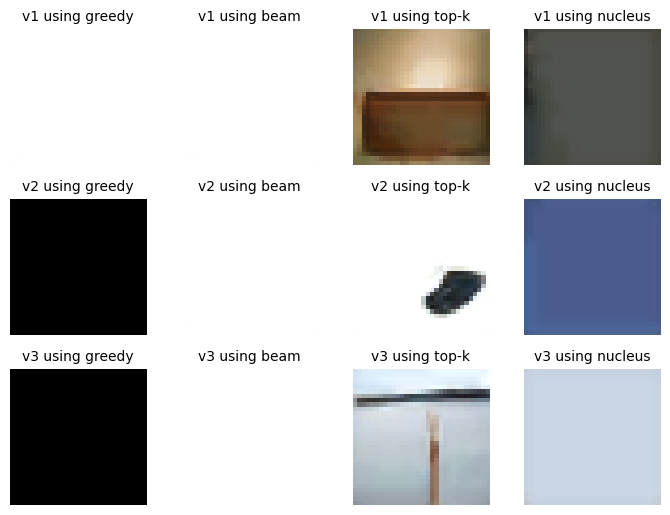

In [ ]:
images = []
titles = []
methods = ["greedy", "beam", "top-k", "nucleus"]
for model_name, _ in gpt_models.items():
  for method in methods:
    _, _, image, _ = generate_image(model_name = model_name, length_context = 0, method = method)
    titles.append(f"{model_name} using {method}")
    images.append(image)

show_multiple_images(images, titles, 3, 4)

These results show that when our models are asked to generate a completely random image from scratch, they tend to produce overly simplistic outputs. However, we observe noticeable differences across the various sampling and decoding strategies.

When using greedy decoding or beam search, the generated images are entirely monochromatic, typically either completely white or completely black.

With nucleus sampling, the outputs remain largely monochromatic, but the colors differ from pure white or black.

In contrast, top-k sampling produces significantly more diverse and structurally complex images for each model. Compared to the other techniques, the outputs appear less trivial and more detailed. For example, starting from model v1, one might vaguely recognize shapes resembling a wooden table viewed from above, a piece of charcoal, or a torch.

Overall, these findings *suggest that our models require substantially more training to generate semantically meaningful images*. Additionally, a larger and more diverse training dataset would likely improve the quality and coherence of the generated outputs.

### 2.5.3 Half image generation
We now turn to the main objective of the project: completing the right-hand side of an image using our language model. Specifically, we provide the first 160 tokens as contextual input and task the model with generating the remaining portion of the image accordingly.

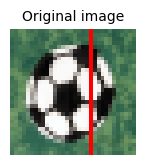

In [ ]:
# See a the original image
random.seed(SEED)
img, _ = test_data[random.randint(0, len(test_data) - 1) + 31]
show_multiple_images([add_red_line(img, image_configuration['num_to_keep_for_partial'])], ["Original image"], 1, 1)

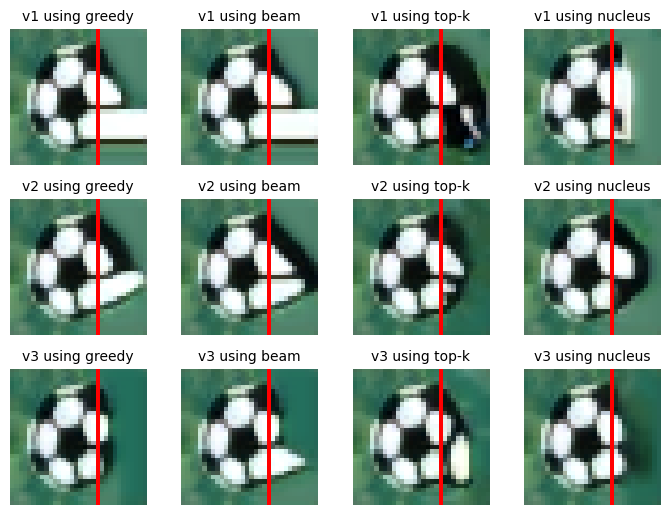

In [ ]:
images = []
titles = []
# Show the generated images to complete it
methods = ["greedy", "beam", "top-k", "nucleus"]
for model_name, _ in gpt_models.items():
  for method in methods:
    _, _, generated_img, _ = generate_image(model_name = model_name, original_img = img, length_context = image_configuration['num_to_keep_for_partial'], method = method)
    titles.append(f"{model_name} using {method}")
    images.append(add_red_line(generated_img, image_configuration['num_to_keep_for_partial']))

show_multiple_images(images, titles, 3, 4)

The results indicate that image completion is not entirely random, unlike image generation from scratch. From this example, we can observe that for model v1, the outputs appear noticeably worse compared to the other two models. Additionally, it seems that sampling-based strategies are more effective at completing the image than greedy or beam search decoding.

# **3. Image Evaluation**

## 3.1. Metrics and comparisons
So now we have to check the quality of the generated image.
Our goal is generate a slice of an image in a way that for a human is indistinguishable from the original version.

For sure we have to check only the slice that the model generates and not all the image, to not get biased in the analysis (we would get too much optimistic results). So we can have a correct view of the generation capacity.

We decided to check the generated image **G** with the original image **O** because it reprents the mesure of correctness between the inference and the Ground Truth, so the final goal.

We decided to use the following 3 metrics:
- Mean Squared Error (**MSE**): quantifies the mean quadratic distance between pixels and so severely penalizes colors completely wrong (Glitch)
  $$MSE=\frac{1}{n}\sum_{i=1}^n(A_i-B_i)^2$$
- Peak Signal-to-Noise Ratio (**PSNR**): express the ratio between the maximal power of the signal and the noise in dB and so the resistence to the lost of information affected by compression (very useful because we have a reconstruction step that filter the image). The more is hight the better is the quality $$PSNR=10\cdot \log_{10}(\frac{MAX^2}{MSE})$$
Where MAX is the maximal value of pixel in the image.
- Structural Similarity Index (**SSIM**): evaluate human visual perception, considering the structural degradation, constrast and luminosity. It's fundamental because it gives a direct information of what a human see beyond some errors that actually he cannot see.
$$SSIM=\frac{1}{p}\sum_{i=1}^p SSIM_i(A^i,B^i)\\ SSIM_i(A^i,B^i)=l(A^i,B^i)^\alpha \cdot c(A^i,B^i)^\beta \cdot s(A^i,B^i)^\gamma $$
Where SSIM is calculated in blocks and then made the average. **s** is a function to calculate the structure, **c** the contrast and **l** the luminance of the blocks of image.

The following code allows to crop the generated image and to calculate the 3 metrics.

In [ ]:
ssim = StructuralSimilarityIndexMeasure().to(device)
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)

# FUNZIONE CHE PRENDE SOLO LA PARTE DESTRA DELL'IMMAGINE (QUELLA GENERATA)
def crop_rightmost_tensor(img):
    "Crop the image into the generation area returning the correct tensor used in evaluation"
    if img.dim() == 3:
        img = img.unsqueeze(0)

    B, C, H, W = img.shape
    k = int((image_configuration['num_to_keep_for_partial'] * (int(cv_configuration['patch_size'])**2)) / 32)
    if k < 0 or k >= W:
        raise ValueError("k fuori range")

    return img[:, :, :, k+1:]

# FUNZIONE CHE CALCOLA LE VARIE METRICHE TRA IMMAGINE ORIGINALE E IMMAGINE GENERATA
def quality_checking(A, B):
  "Return metrics for tensor A against tensor B"
  img_height, img_width = A.shape[-2:]

  A_s = crop_rightmost_tensor(A).to(device)
  B_s = crop_rightmost_tensor(B).to(device)

  v_ssim = ssim(A_s, B_s)
  v_psnr = psnr(A_s, B_s)
  v_mse = torch.mean((A_s - B_s)**2)

  return v_ssim.item(), v_psnr.item(), v_mse.item()

Now we observe how metrics evaluate an image generated by 3 models using top-k sampling method (you can also try with a different method)

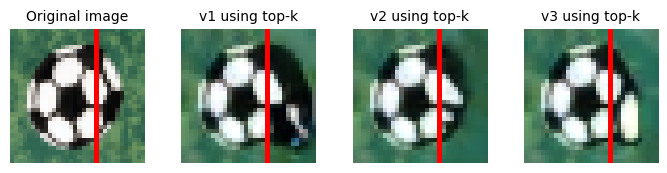


Metrics for v1 using top-k:
SSIM: 0.0455
PSNR: 10.1792
MSE: 0.0960
--------------------------------------------------
Metrics for v2 using top-k:
SSIM: 0.1140
PSNR: 11.1480
MSE: 0.0768
--------------------------------------------------
Metrics for v3 using top-k:
SSIM: 0.0468
PSNR: 10.0251
MSE: 0.0994
--------------------------------------------------


In [ ]:
titles = []
images_to_show = []
images_to_evaluate = []
titles.append(f"Original image")
images_to_show.append(add_red_line(img, image_configuration['num_to_keep_for_partial']))

for i, image in enumerate(images):
  if i % 4 == 2:
      titles.append(f"v{(i+2) // 4} using top-k")
      images_to_evaluate.append(image)
      images_to_show.append(add_red_line(image, image_configuration['num_to_keep_for_partial']))

show_multiple_images(images_to_show, titles, 1, 4)
print()

for i, image_to_evaluate in enumerate(images_to_evaluate):
  ssim_, psnr_, mse_ = quality_checking(img, image_to_evaluate)
  print(f"Metrics for v{i+1} using top-k:")
  print(f"SSIM: {ssim_:.4f}")
  print(f"PSNR: {psnr_:.4f}")
  print(f"MSE: {mse_:.4f}")
  print("-"*50)

We notice how SSIM penalize more v1 and v3 model because the structures seems to be more distorted. All the 3 metrics generaly identify the best model but SSIM and PSNR seems to highlight more the error (remember that PSNR is in dB so passing from 10 to 11 is very relevant).

## 3.2. Different Models and Sampling methods
Because we want to test and find which is the best model and method, we have to use the metrics and all the testing set of images on each combination.
The metrics calculation is not very heavy and is very fast but the generation can take very long. For this reason the following blocks allows to save a dataset of the cropped original images and a dataset of cropped generated images for each combination. The generation is made in batch and allows to re-run from last interruption (because of the timeout on GPU from google colab).
We decided to reduce the testing dataset at 1000 images because 50.000 would have taken too much time and space (there are 12 combinations).



In [ ]:
methods = ["top-k", "nucleus", "beam", "greedy"]
models = ["v1", "v2", "v3"]

In [ ]:
# GNEERA BATCH DI IMMAGINI RICOSTRUITE E GENERATE A PARTIRE DA QUELLE ORIGINALI
@torch.no_grad()
def batch_generation(batch_imgs,network_name,method_name):
  batch_imgs=batch_imgs.to(device)
  batch_size=batch_imgs.size(0)

  #Get tokens from images with VQVAE
  _, _, _, tokens=vqvae_model(batch_imgs)

  #Flattening (B, 16, 16) -> (B, 256)
  tokens_flat=tokens.permute(0, 2, 1).contiguous().view(batch_size, -1)

  #Preparation
  num_to_keep=image_configuration['num_to_keep_for_partial']
  start_token=torch.tensor([[lm_configuration['start_token']]], device=device).repeat(batch_size, 1)
  if num_to_keep > 0:
      prefix=torch.cat([start_token, tokens_flat[:, :num_to_keep]], dim=1)
  else:
      prefix=start_token

  #Generation
  start = time.time()
  completed_tokens=generate_image_tokens(
      model_name = network_name,
      prefix_idx=prefix,
      method=method_name
  )
  end = time.time()
  elapsed = end - start

  gen_tokens_no_start=completed_tokens[:, 1:] #start token remotion

  #Quantized image
  z_q_orig=vqvae_model.quantizer.codebook(tokens.permute(0, 2, 1).contiguous()) # (B, H, W, D)
  z_q_orig=z_q_orig.permute(0, 3, 1, 2).contiguous()
  recon_original_imgs=vqvae_model.decoder(z_q_orig).clamp(0.0, 1.0)

  #Generated image
  generated_imgs=tokens_to_image(gen_tokens_no_start)

  #Cropping
  recon_cropped=crop_rightmost_tensor(recon_original_imgs)
  gen_cropped=crop_rightmost_tensor(generated_imgs)
  orig_cropped=crop_rightmost_tensor(batch_imgs)
  return recon_cropped, gen_cropped, orig_cropped,elapsed

#
def get_start_index(checkpoint_dir,file_pref):
    """
    Check existing batch files and return the index from which to re-start for the generation
    """
    #Check files in checkpoint dir
    files = glob.glob(os.path.join(checkpoint_dir, f"{file_pref}batch_*.pt"))

    if not files:
        return 0 #No files of the combination is present, begin from the first batch

    #Sort batch files of the combination
    files.sort(key=lambda f: int(re.search(r'batch_(\d+).pt', f).group(1)))

    last_file = files[-1] #take the last name
    print(f"Found {len(files)} batch saved")

    #extract the index present in the name and return it
    restart_index = int(re.search(r'batch_(\d+).pt', last_file).group(1))
    return restart_index+1

def datasets_for_models_and_methods(network_name="v1",method_name="top-k",subset_dim=1000):
  """
    For a specific combination of model and method:
    Call generation of batch of images, saving also the elasped time. Then group the generation
    batch with original batch, cutting only the generation area and save it in a Checkpoint dir,
    allowing to call multiple times to re-start in case of runtime crash.
    The following are the supported combinations.
    network_name:
        - v1 : gpt_imagenet_v3_2x2_128_8_6
        - v2 : gpt_imagenet_v5_2x2_256_8_8
        - v3 : gpt_imagenet_v6_2x2_512_8_8
    method_name:
        - top-k
        - nucleus
        - beam
        - greedy
  """
  CHECKPOINT_DIR=os.path.join(persistent_storage.get_base_path(),"checkpoints")
  test_subset = Subset(test_data, range(subset_dim))
  input_loader=torch.utils.data.DataLoader(
      test_subset,
      batch_size=256,
      shuffle=False,
      num_workers=2
  )

  start_batch_index = get_start_index(CHECKPOINT_DIR,f"{network_name}_{method_name}_")
  print(f"Re-start computation from batch index: {start_batch_index}")

  for i, (batch_imgs, _) in enumerate(tqdm(input_loader, initial=start_batch_index, total=len(input_loader))):

      #Skip batch just saved
      if i < start_batch_index:
          continue

      #Generate batch of image cropped
      recon_cropped, gen_cropped, orig_cropped, elapsed_time = batch_generation(batch_imgs,network_name,method_name)


      #Build the checkpoint of the batch (dict of batches of images)
      batch_data = {
          'recon': recon_cropped.cpu(),
          'gen': gen_cropped.cpu(),
          'orig': orig_cropped.cpu(),
          'time': elapsed_time
      }

      #Save the checkpoint
      save_path = os.path.join(CHECKPOINT_DIR, f"{network_name}_{method_name}_batch_{i}.pt")
      torch.save(batch_data, save_path)


def merge_datasets(network_name="v1",method_name="top-k",finalsave=False):
    """
    Join batch checkpoints saved by datasets_for_models_and_methods() in a dataset for each type:
    original image and generated image. Then deletes checkpoints.
    When finalsave=True, it is considered the case of Chapter 5. (dataset of all the testing dataset, not only 1000 sample)
    """
    CHECKPOINT_DIR=os.path.join(persistent_storage.get_base_path(),"checkpoints")
    DATASETS_DIR=os.path.join(persistent_storage.get_base_path(),"datasets")

    print("Joining batch...")
    files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, f"{network_name}_{method_name}_batch_*.pt")),
                   key=lambda f: int(re.search(r'batch_(\d+).pt', f).group(1)))

    all_recon = []
    all_gen = []
    all_orig = []
    all_times = []

    for f in tqdm(files, desc="Merging"):
        data = torch.load(f)
        all_recon.append(data['recon'])
        all_gen.append(data['gen'])
        all_orig.append(data['orig'])
        all_times.append(data['time'])

    #Concatenation
    full_recon = torch.cat(all_recon, dim=0)
    full_gen = torch.cat(all_gen, dim=0)
    full_orig = torch.cat(all_orig, dim=0)

    print("Removing temporary batch...")
    for f in files:
        try:
            os.remove(f)
        except OSError as e:
            print(f"Cannot delete file {f}: {e}")

    if finalsave: #For chapter 5.
      torch.save(full_orig, os.path.join(DATASETS_DIR,"final_original.pt"))
      torch.save(full_recon, os.path.join(DATASETS_DIR,"final_reconstract.pt"))
      torch.save(full_gen, os.path.join(DATASETS_DIR,f"final_dataset_generated.pt"))
      persistent_storage.save_data_structure(all_times, os.path.join(DATASETS_DIR,"final_batch_generation_time"))
    else:
      torch.save(full_orig, os.path.join(DATASETS_DIR,"dataset_original.pt"))
      torch.save(full_recon, os.path.join(DATASETS_DIR,"dataset_reconstract.pt"))
      torch.save(full_gen, os.path.join(DATASETS_DIR,f"{network_name}_{method_name}_dataset_generated.pt"))
      persistent_storage.save_data_structure(all_times, os.path.join(DATASETS_DIR,f"{network_name}_{method_name}_batch_generation_time"))

In [ ]:
#Dataset generation for each combination
for model in models:
  for method in methods:
    if not os.path.exists(os.path.join(persistent_storage.get_base_path(),"datasets",f"{model}_{method}_dataset_generated.pt")):
      print(f"Build Datasets for {model}_{method}")
      datasets_for_models_and_methods(network_name=model,method_name=method)
      merge_datasets(network_name=model,method_name=method)
    else:
      print(f"Datasets for {model}_{method} already present")

Datasets for v1_top-k already present
Datasets for v1_nucleus already present
Datasets for v1_beam already present
Datasets for v1_greedy already present
Datasets for v2_top-k already present
Datasets for v2_nucleus already present
Datasets for v2_beam already present
Datasets for v2_greedy already present
Datasets for v3_top-k already present
Datasets for v3_nucleus already present
Datasets for v3_beam already present
Datasets for v3_greedy already present


## 3.3. Evaluate the Efficiency


In the generation step we also saved the time elapsed during block generation.
We provide an heatmap representing which combination is fast and which is slow.

Compute the elapsed times...



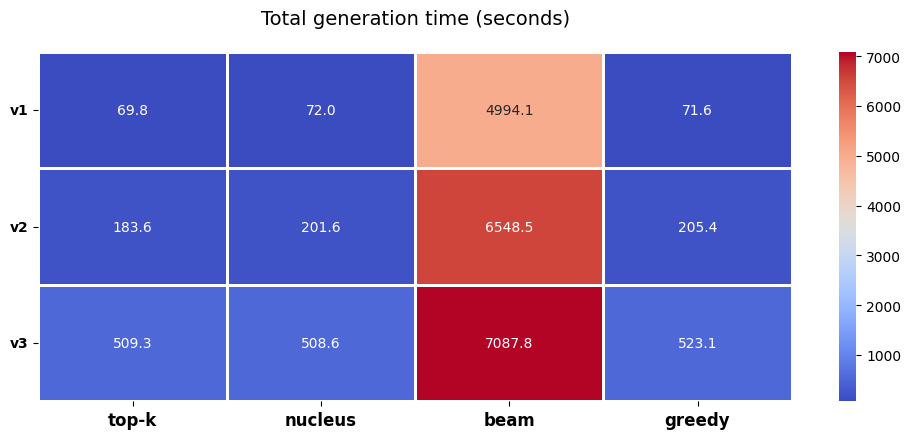

In [ ]:
def generation_strategies_confront_times(methods,models):
  DATASETS_DIR=os.path.join(persistent_storage.get_base_path(),"datasets")

  print("Compute the elapsed times...")

  time_matrix = np.zeros((len(models), len(methods)))

  for r, mod in enumerate(models):
      for c, met in enumerate(methods):
          path_time=os.path.join(DATASETS_DIR,f"{mod}_{met}_batch_generation_time")
          if not os.path.exists(path_time+".pickle"):
              print(f"Skip {path_time}: non trovato")
              continue
          all_times=persistent_storage.load_data_structure(path_time, verbose = False)
          total_time = sum(all_times)
          time_matrix[r, c] = total_time

  print("")

  #Time PLOT
  plt.figure(figsize=(len(methods) * 2.5, len(models) * 1.5))

  ax = sns.heatmap(time_matrix, annot=True, fmt=".1f",
                  cmap='coolwarm', cbar=True,
                  linewidths=1, linecolor='white')

  ax.set_yticklabels(models, rotation=0, fontsize=10, fontweight='bold')
  ax.set_xticklabels(methods, rotation=0, fontsize=12, fontweight='bold')

  plt.title("Total generation time (seconds)", fontsize=14, pad=20)
  plt.tight_layout()
  plt.show()

generation_strategies_confront_times(methods,models)

We observe that the **Beam** approach is significantly slower, while **v2** achieves approximately twice the performance of **v3** (and similarly, **v1** is about twice as fast as **v2**). This behavior was expected, given the intrinsic characteristics of the Beam algorithm, which prioritizes exhaustive exploration and optimality over computational efficiency.

## 3.4. Evaluate the Effectiveness
Now we generate an heatmap that sum up all the metrics on different combination.

Compute the metrics...



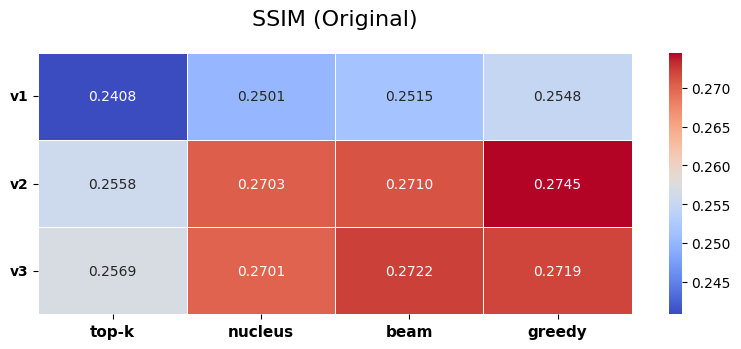

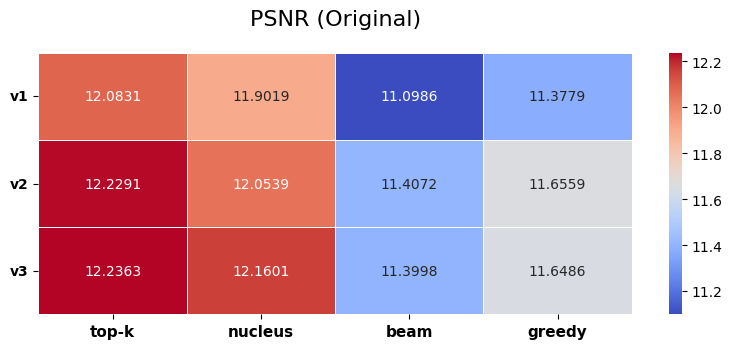

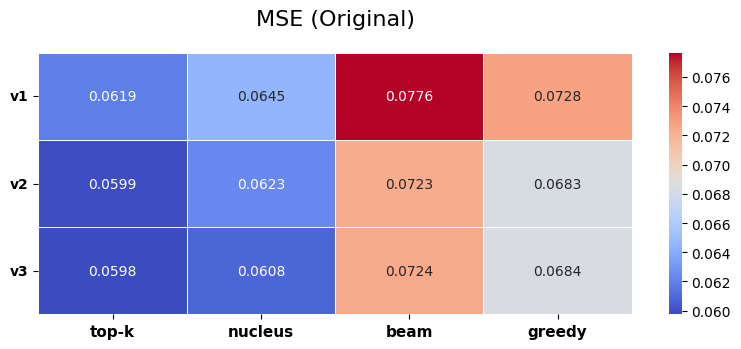

In [ ]:
def plot_original_heatmap(metric_name, data_matrix, methods, models):
    original_data = data_matrix[:, ::2]
    plt.figure(figsize=(len(methods) * 2, len(models) * 1.2))
    ax = sns.heatmap(original_data,
                     annot=True,
                     fmt=".4f",
                     cmap='coolwarm',
                     cbar=True,
                     linewidths=0.5,
                     linecolor='white')


    ax.set_yticklabels(models, rotation=0, fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(len(methods)) + 0.5)
    ax.set_xticklabels(methods, rotation=0, fontsize=11, fontweight='bold')
    plt.title(f"{metric_name} (Original)", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()


def generation_strategies_confront_metrics(methods,models,sample_limit = 1000):
  DATASETS_DIR=os.path.join(persistent_storage.get_base_path(),"datasets")

  #Dataset load
  full_orig = torch.load(os.path.join(DATASETS_DIR, "dataset_original.pt"))
  full_recon = torch.load(os.path.join(DATASETS_DIR, "dataset_reconstract.pt"))

  #Extract the subset (if needed)
  orig_subset = full_orig[:sample_limit].to(device)
  recon_subset = full_recon[:sample_limit].to(device)


  print("Compute the metrics...\n")
  metrics_names = ['SSIM', 'PSNR', 'MSE']
  metrics_data = {m: np.zeros((len(models), len(methods) * 2)) for m in metrics_names} #in case some combination were not generated, set the values to 0

  for r, mod in enumerate(models):
      for c, met in enumerate(methods):

          #Load generated dataset specific to a combination
          gen_path = os.path.join(DATASETS_DIR, f"{mod}_{met}_dataset_generated.pt")
          if not os.path.exists(gen_path):
              print(f"Skip {gen_path}: not found")
              continue

          full_gen = torch.load(gen_path)
          gen_subset = full_gen[:sample_limit].to(device)


          #Metrics calculation
          val_ssim_o = ssim(gen_subset, orig_subset).mean().item()
          val_psnr_o = psnr(gen_subset, orig_subset).mean().item()
          val_mse_o = torch.mean((gen_subset - orig_subset)**2).item()

          #Saving calculation for the heatmap
          col_idx = c * 2
          metrics_data['SSIM'][r, col_idx] = val_ssim_o
          metrics_data['PSNR'][r, col_idx] = val_psnr_o
          metrics_data['MSE'][r, col_idx] = val_mse_o

  #PLOT GENERATION for each metric
  for name in metrics_names:
      plot_original_heatmap(name, metrics_data[name],methods,models)
      print()

generation_strategies_confront_metrics(methods,models)

SSIM indicates that **v2** and **v3** are the best-performing models when using nucleus, beam, or greedy sampling methods. It also shows that these combinations introduce roughly the same level of distortion in the generated images.

Since the differences in MSE between combinations are minimal, we cannot rely on it to select the best model; instead, we turn to PSNR.

Based on PSNR, nucleus sampling outperforms both beam and greedy by a meaningful margin—note that even a 0.1 difference on the decibel scale is significant. Overall, the **best-performing combinations seem to be v2 with nucleus sampling and v3 with nucleus sampling**.

# **4. Significance Testing**
We now conduct a statistical significance test to assess whether the observed differences in the models between our `v2_nucleus` system and the `v3_nucleus` system are meaningful. The comparison is performed using the Wilcoxon signed-rank test, a non-parametric test suitable for paired observations, with the significance level set to α = 0.05.

In [ ]:
def significance_testing(model1, method1, model2, method2, alpha = 0.05, sample_limit = 1000):

    DATASETS_DIR = os.path.join(persistent_storage.get_base_path(), "datasets")

    # Loading the dataset of images
    full_orig = torch.load(os.path.join(DATASETS_DIR, "dataset_original.pt"))
    orig_subset = full_orig[:sample_limit].to(device)

    gen_A = torch.load(os.path.join(DATASETS_DIR, f"{model1}_{method1}_dataset_generated.pt"))[:sample_limit].to(device)
    gen_B = torch.load(os.path.join(DATASETS_DIR, f"{model2}_{method2}_dataset_generated.pt"))[:sample_limit].to(device)

    ssim_A_vals, ssim_B_vals = [], []
    psnr_A_vals, psnr_B_vals = [], []
    mse_A_vals, mse_B_vals = [], []

    print(f"The significant testing is performed to compare {model1}_{method1} and {model2}_{method2}")

    # We compute the metrics for all images at a time
    for i in range(sample_limit):

        img_orig = orig_subset[i].unsqueeze(0)
        img_A = gen_A[i].unsqueeze(0)
        img_B = gen_B[i].unsqueeze(0)

        # SSIM
        ssim_A_vals.append(ssim(img_A, img_orig).item())
        ssim_B_vals.append(ssim(img_B, img_orig).item())

        # PSNR
        psnr_A_vals.append(psnr(img_A, img_orig).item())
        psnr_B_vals.append(psnr(img_B, img_orig).item())

        # MSE
        mse_A_vals.append(torch.mean((img_A - img_orig)**2).item())
        mse_B_vals.append(torch.mean((img_B - img_orig)**2).item())

    # We do the test for a metric at a time
    for name, A_vals, B_vals in [
        ("SSIM", ssim_A_vals, ssim_B_vals),
        ("PSNR", psnr_A_vals, psnr_B_vals),
        ("MSE", mse_A_vals, mse_B_vals),
    ]:

        print(f"\n###### Performing Wilcoxon Test for {name} ######")

        # Execute the Wilcoxon signed-rank test is a non-parametric rank test
        # for statistical hypothesis testing
        try:
            A_vals = np.array(A_vals)
            B_vals = np.array(B_vals)
            mean_diff = (A_vals - B_vals).mean()
            stat, p_value = st.wilcoxon(A_vals, B_vals)
        except ValueError:
            # If the set of data are the same, the function generate an
            # exception if the two sets are identical
            print(f"Is not possible to execute the Wilcoxon Test for {name} because the sets are identical.\n")
            continue

        print(f"Statistic: {stat:.1f}")
        print(f"P-value: {p_value:.3f}")
        print("")

        # Compare the p-value obtained with the significance level alpha
        if p_value > alpha:
            print(f"The difference is not statistically significant (p-value > {alpha}).")
            print("We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.")
        else:
            print(f"The difference is statistically significant (p-value <= {alpha}).")
            print("We can reject the null hypothesis therefore the **performances of the systems are considered different** for this metric.")
            if mean_diff > 0:
                print(f"The system {model1}_{method1} is significantly better")
            else :
               print(f"The system {model2}_{method2} is significantly better")
    return

In [ ]:
significance_testing("v3", "nucleus", "v2", "nucleus")

The significant testing is performed to compare v3_nucleus and v2_nucleus

###### Performing Wilcoxon Test for SSIM ######
Statistic: 247971.0
P-value: 0.803

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.

###### Performing Wilcoxon Test for PSNR ######
Statistic: 246556.0
P-value: 0.686

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.

###### Performing Wilcoxon Test for MSE ######
Statistic: 247593.0
P-value: 0.771

The difference is not statistically significant (p-value > 0.05).
We cannot reject the null hypothesis therefore the **performances of the systems are considered similar** for this metric.


Statistical significance tests were conducted, and the differences between the models were found **to be not statistically significant**. Therefore, **according to Occam’s Razor principle**, **it is reasonable to prefer the v2 model**, as it achieves faster generation while maintaining comparable performance, and it is also architecturally simpler.

# **5. Final testing**
In the following code we demonstrate that metrics remain almost the same calculating over 50.000 images instead of 1000 for v2 nucleus and assume that it quite the same for the other combinations.

In [ ]:
if not os.path.exists(os.path.join(persistent_storage.get_base_path(),"datasets","final_dataset_generated.pt")):
  datasets_for_models_and_methods(network_name="v2",method_name="nucleus",subset_dim=50000)
  merge_datasets(network_name="v2",method_name="nucleus",finalsave=True)
  print(f"Build Datasets for final testing")
else:
  print(f"Datasets for final testing already present")

Datasets for final testing already present


In [ ]:
print(f"Global Testing on {len(test_data)} images...")

@torch.no_grad()
def process_batch_metrics(orig_cropped,gen_cropped,ssim, psnr):
    val_ssim_o = ssim(gen_cropped, orig_cropped).item()
    val_psnr_o = psnr(gen_cropped, orig_cropped).item()
    val_mse_o = torch.mean((gen_cropped - orig_cropped)**2).item()

    return (val_ssim_o, val_psnr_o, val_mse_o)

def final_testing():
  '''
  Caculate the mean and stdev of batch of images
  '''
  ssim = StructuralSimilarityIndexMeasure().to(device)
  psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)

  DATASETS_DIR=os.path.join(persistent_storage.get_base_path(),"datasets")

  original = torch.load(os.path.join(DATASETS_DIR,"final_original.pt"))
  generated = torch.load(os.path.join(DATASETS_DIR,f"final_dataset_generated.pt"))
  times=persistent_storage.load_data_structure(os.path.join(DATASETS_DIR,"final_batch_generation_time"), verbose = False)

  metrics_o = {'ssim': [], 'psnr': [], 'mse': []}

  # Creating DataLoaders for the loaded tensors
  original_loader = DataLoader(original, batch_size=256, shuffle=False)
  generated_loader = DataLoader(generated, batch_size=256, shuffle=False)

  for batch_orig, batch_gen in tqdm(zip(original_loader, generated_loader), total=len(original_loader)):
      res_o = process_batch_metrics(batch_orig.to(device), batch_gen.to(device), ssim, psnr)

      metrics_o['ssim'].append(res_o[0])
      metrics_o['psnr'].append(res_o[1])
      metrics_o['mse'].append(res_o[2])

  print("\n#======Original vs Generated======#")
  print('{2} \t\t Average: {0:.4f} \t Stdev: {1:.4f}'.format(statistics.mean(metrics_o['ssim']),statistics.stdev(metrics_o['ssim']),"[SSIM]"))
  print('{2} \t\t Average: {0:.4f} \t Stdev: {1:.4f}'.format(statistics.mean(metrics_o['psnr']),statistics.stdev(metrics_o['psnr']),"[PSNR]"))
  print('{2} \t\t Average: {0:.4f} \t Stdev: {1:.4f}'.format(statistics.mean(metrics_o['mse']),statistics.stdev(metrics_o['mse']),"[MSE] "))


final_testing()


Global Testing on 50000 images...


  0%|          | 0/196 [00:00<?, ?it/s]


#======Original vs Generated======#
[SSIM] 		 Average: 0.2727 	 Stdev: 0.0113
[PSNR] 		 Average: 11.9534 	 Stdev: 0.2351
[MSE]  		 Average: 0.0639 	 Stdev: 0.0035


# **Bibliography**

**About imagenet32 dataset**:
- *imagenet32 - Source of donwload* : [Source](https://image-net.org/download-images.php)

**About VQ-VAE architecture**:
- *VQ-VAE - Youtube video explaination* : [Source](https://www.youtube.com/watch?v=1ZHzAOutcnw)

**About ImageGPT**:
- *ImageGPT-OpenAI* : [Source](https://openai.com/index/image-gpt/)
- VQVAE + GPT : [Source](https://github.com/BhanuPrakashPebbeti/Image-Generation-Using-VQVAE)
